# ECAPA-TDNN finetuning — improved (Common Voice PL)

Wersja ulepszona vs `ecapa_finetune_orig.ipynb`. Zachowana struktura, dodane następujące techniki:

**Tier A — szybkie wygrane (zero/near-zero compute cost):**
- Mixed Precision Training (AMP) — ~2× szybciej na A100
- BATCH_SIZE 64 → 192 (wykorzystanie A100 40 GB)
- AdamW + weight decay (regularizacja)
- Warmup (1 epoka) + cosine LR schedule
- Gradient clipping (norm=5.0)
- AAM margin curriculum (0.0 → 0.2 w 4 epokach)

**Tier B — strukturalne ulepszenia:**
- Speaker-balanced batch sampler (M=64 mówców × N=3 nagrania/batch)
- SEGMENT_SECONDS 3.0 → 4.0
- Sub-center AAM-Softmax (K=3 sub-centers/klasa)
- Multi-crop TTA przy ewaluacji (3 cropy uśrednione)
- AS-norm (Adaptive Score Normalization) na ewaluacji

**Tier C — zaawansowane augmentacje + LMFT:**
- Speed Perturbation (0.9× / 1.0× / 1.1×, offline preprocessing)
- SpecAugment intensification (3 maski, time_mask=35)
- Phase 3 — Large Margin Fine-Tuning (margin=0.5, segment=6s, 2 epoki)

Oczekiwane wyniki: dev EER **0.0452 → ~0.025–0.030** (orig vs improved).

In [ ]:
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
import torch

# Instalacja zależności (najnowsza wersja speechbrain rozwiązuje problemy z kompatybilnością)
#!pip install -q speechbrain pandas tqdm scikit-learn matplotlib
#!apt-get -qq install -y ffmpeg

## Konfiguracja

Wszystkie hiperparametry w jednym miejscu. Komentarze przy zmianach vs orig.

In [2]:
from pathlib import Path

DRIVE_BASE = Path("/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2")

# --- Ścieżki ---
TAR_GZ_PATH  = DRIVE_BASE / "cv-corpus-25.0-2026-03-09-pl.tar.gz"
RESULTS_DIR  = DRIVE_BASE / "results_improved"  # osobny folder

EXTRACT_DIR  = DRIVE_BASE / "cv_pl_extracted"
WAV_DIR      = DRIVE_BASE / "wav_16k"
PRETRAINED_DIR = DRIVE_BASE / "pretrained_ecapa"

# --- Filtrowanie / podział ---
MIN_CLIPS_PER_SPEAKER = 10
MAX_CLIPS_PER_SPEAKER = 50
TRAIN_RATIO = 0.70
DEV_RATIO   = 0.15
TEST_RATIO  = 0.15

# --- Audio ---
TARGET_SR        = 16000
SEGMENT_SECONDS  = 4.0               # was 3.0 — dłuższe okno, lepszy embedding
EVAL_MAX_SECONDS = 8.0
EVAL_CROP_SECONDS = 4.0              # długość pojedynczego cropu przy TTA

# --- ECAPA / AAM-Softmax ---
EMBEDDING_SIZE     = 192
AAM_S              = 30.0
AAM_MARGIN_FINAL   = 0.2             # docelowy margines po curriculum
MARGIN_RAMP_EPOCHS = 4               # epok do osiągnięcia max marginesu (faza 2)
SUBCENTER_K        = 3               # sub-center AAM-Softmax (K=3 sub-centers/klasa)

# --- Trening (Tier A) ---
USE_AMP        = True                # mixed precision na A100
BATCH_SIZE     = 192                 # was 64 — wykorzystanie pamięci A100
NUM_WORKERS    = 4                   # was 2
PHASE1_LR      = 1e-4                # was 1e-3 — niższy, stabilniejszy
PHASE1_EPOCHS  = 5
PHASE2_LR      = 2e-5                # was 1e-5 — wyższy, kompensowany warmupem+cosine
PHASE2_EPOCHS  = 15
WEIGHT_DECAY   = 2e-5                # AdamW regularization
WARMUP_EPOCHS  = 1                   # liniowy warmup w fazie 2
GRAD_CLIP_NORM = 5.0

# --- Balanced sampler (Tier B) ---
BALANCED_SAMPLER_M = 64              # mówców per batch
BALANCED_SAMPLER_N = 3               # nagrań per mówca
# M*N == BATCH_SIZE = 192

# --- Augmentacje ---
AUG_NOISE_PROB     = 0.5
AUG_NOISE_SNR_DB   = (5, 20)
AUG_GAIN_DB        = 6.0
AUG_SPEED_PROB     = 0.6             # NEW: prob. użycia speed-perturbed wariantu
SPECAUG_FREQ_MASK  = 15
SPECAUG_TIME_MASK  = 35              # was 25
SPECAUG_NUM_MASKS  = 3               # was 2

# --- Ewaluacja ---
NUM_POSITIVE_PAIRS  = 3000
NUM_NEGATIVE_PAIRS  = 3000
EVAL_NUM_CROPS      = 3              # multi-crop TTA
ASNORM_COHORT_SIZE  = 500            # liczba nagrań w cohort
ASNORM_TOP_N        = 300            # top-N do statystyk normalizacji

# --- LMFT (faza 3) ---
LMFT_ENABLED         = True
LMFT_EPOCHS          = 2
LMFT_MARGIN          = 0.5
LMFT_SEGMENT_SECONDS = 6.0
LMFT_LR              = 5e-6
LMFT_BATCH_SIZE      = 96            # mniejszy ze względu na dłuższy segment
LMFT_SAMPLER_M       = 32            # 32 × 3 = 96
LMFT_SAMPLER_N       = 3

SEED = 42

In [3]:
import os
import random
import shutil
import subprocess
import tarfile
import math
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader, Sampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# Reprodukowalność
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"AMP enabled: {USE_AMP}")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
WAV_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
AMP enabled: True


## Rozpakowanie korpusu

Idempotentne — jeśli `EXTRACT_DIR` już zawiera dane, pomijamy rozpakowanie.

In [ ]:
def find_corpus_root(base: Path) -> Path:
    for tsv in base.rglob("validated.tsv"):
        return tsv.parent
    raise FileNotFoundError(f"Nie znaleziono validated.tsv w {base}")

# dataset was unpacked manually on linux

CORPUS_ROOT = find_corpus_root(EXTRACT_DIR)
CLIPS_DIR   = CORPUS_ROOT / "clips"
print(f"CORPUS_ROOT: {CORPUS_ROOT}")
print(f"CLIPS_DIR:   {CLIPS_DIR}  ({sum(1 for _ in CLIPS_DIR.iterdir())} plików)")

CORPUS_ROOT: /net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/cv_pl_extracted/cv-corpus-25.0-2026-03-09/pl
CLIPS_DIR:   /net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/cv_pl_extracted/cv-corpus-25.0-2026-03-09/pl/clips  (148690 plików)


## Filtrowanie i open-set split po `client_id`

Identyczna logika jak w oryginale — ten sam `SEED=42` gwarantuje identyczne splity.

In [5]:
df = pd.read_csv(CORPUS_ROOT / "validated.tsv", sep="\t", low_memory=False)
df = df[["client_id", "path"]].dropna()
print(f"Validated total: {len(df)} klipów, {df['client_id'].nunique()} unikalnych mówców")

counts = df.groupby("client_id").size()
ok_speakers = counts[counts >= MIN_CLIPS_PER_SPEAKER].index
df = df[df["client_id"].isin(ok_speakers)].copy()
print(f"Po filtrze ≥{MIN_CLIPS_PER_SPEAKER} klipów: {len(df)} klipów, {df['client_id'].nunique()} mówców")

df = (df.groupby("client_id", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), MAX_CLIPS_PER_SPEAKER), random_state=SEED)))
print(f"Po cap ≤{MAX_CLIPS_PER_SPEAKER} klipów/mówca: {len(df)} klipów, {df['client_id'].nunique()} mówców")

all_speakers = sorted(df["client_id"].unique())
train_spk, temp_spk = train_test_split(
    all_speakers, test_size=(DEV_RATIO + TEST_RATIO), random_state=SEED
)
dev_spk, test_spk = train_test_split(
    temp_spk, test_size=TEST_RATIO / (DEV_RATIO + TEST_RATIO), random_state=SEED
)
train_spk, dev_spk, test_spk = set(train_spk), set(dev_spk), set(test_spk)

train_id_to_label = {cid: i for i, cid in enumerate(sorted(train_spk))}
num_train_classes = len(train_id_to_label)

def make_records(speakers, with_label=False):
    rows = df[df["client_id"].isin(speakers)]
    if with_label:
        return [(r.path, train_id_to_label[r.client_id]) for r in rows.itertuples()]
    return [(r.path, r.client_id) for r in rows.itertuples()]

train_data = make_records(train_spk, with_label=True)
dev_data   = make_records(dev_spk)
test_data  = make_records(test_spk)

print()
print(f"Train: {len(train_spk)} mówców, {len(train_data)} klipów  ({num_train_classes} klas)")
print(f"Dev:   {len(dev_spk)} mówców, {len(dev_data)} klipów")
print(f"Test:  {len(test_spk)} mówców, {len(test_data)} klipów")

for name, spk in [("train_split.txt", train_spk), ("valid_split.txt", dev_spk), ("test_split.txt", test_spk)]:
    (RESULTS_DIR / name).write_text("\n".join(sorted(spk)) + "\n")
    print(f"Zapisano {name}: {len(spk)} mówców")

Validated total: 138292 klipów, 3333 unikalnych mówców
Po filtrze ≥10 klipów: 129481 klipów, 1353 mówców
Po cap ≤50 klipów/mówca: 36087 klipów, 1353 mówców

Train: 947 mówców, 25349 klipów  (947 klas)
Dev:   203 mówców, 5470 klipów
Test:  203 mówców, 5268 klipów
Zapisano train_split.txt: 947 mówców
Zapisano valid_split.txt: 203 mówców
Zapisano test_split.txt: 203 mówców


/net/tscratch/people/plgmarcintkocz/slurm_jobdir/2616167/tmp.t0033/ipykernel_2164256/64096070.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = (df.groupby("client_id", group_keys=False)


## Pre-konwersja MP3 → WAV 16 kHz mono

Identycznie jak w oryginale. Jednorazowe, idempotentne.

In [10]:
def wav_path_for(client_id: str, mp3_name: str) -> Path:
    return WAV_DIR / client_id / (Path(mp3_name).stem + ".wav")

needed = []
for spk_set in (train_spk, dev_spk, test_spk):
    for r in df[df["client_id"].isin(spk_set)].itertuples():
        mp3 = CLIPS_DIR / r.path
        wav = wav_path_for(r.client_id, r.path)
        needed.append((mp3, wav))

print(f"Klipów do konwersji: {len(needed)}")

Klipów do konwersji: 36087


In [7]:
def mp3_to_wav(mp3_path: Path, wav_path: Path) -> bool:
    if wav_path.exists():
        return True
    wav_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = ["/net/people/plgrid/plgmarcintkocz/bin/ffmpeg-7.0.2-amd64-static/ffmpeg", "-y", "-loglevel", "error",
           "-i", str(mp3_path),
           "-ar", str(TARGET_SR), "-ac", "1",
           "-c:a", "pcm_s16le", str(wav_path)]
    try:
        subprocess.run(cmd, check=True, capture_output=True)
        return True
    except subprocess.CalledProcessError:
        return False

In [24]:
failed = 0
#with ThreadPoolExecutor(max_workers=max(2, os.cpu_count() or 2)) as ex:
with ThreadPoolExecutor(max_workers=40) as ex:
    futures = [ex.submit(mp3_to_wav, mp3, wav) for mp3, wav in needed]
    for fut in tqdm(as_completed(futures), total=len(futures), desc="MP3→WAV"):
        if not fut.result():
            failed += 1

print(f"Konwersja zakończona. Błędów: {failed}")

MP3→WAV:   0%|          | 0/36087 [00:00<?, ?it/s]

Konwersja zakończona. Błędów: 0


In [11]:
path_to_cid = dict(zip(df["path"], df["client_id"]))

def to_wav_records(records, with_label):
    out = []
    for mp3_name, key in records:
        cid = path_to_cid[mp3_name] if with_label else key
        wav = wav_path_for(cid, mp3_name)
        if wav.exists():
            out.append((str(wav), key))
    return out

train_data = to_wav_records(train_data, with_label=True)
dev_data   = to_wav_records(dev_data,   with_label=False)
test_data  = to_wav_records(test_data,  with_label=False)
print(f"Po filtracji do istniejących WAV-ów:")
print(f"  train: {len(train_data)}, dev: {len(dev_data)}, test: {len(test_data)}")

Po filtracji do istniejących WAV-ów:
  train: 25349, dev: 5470, test: 5268


## Model: ECAPA-TDNN backbone + Sub-Center AAM-Softmax

- Pretrained ECAPA z SpeechBrain (192-D, ~20.7M params)
- `SubCenterArcMarginProduct(K=3)` — robust to noisy labels (Common Voice ma różne warunki nagrania per mówca)
- `set_margin()` umożliwia curriculum learning

In [15]:
import huggingface_hub
import huggingface_hub.file_download
from speechbrain.inference.speaker import EncoderClassifier

# Tworzymy pusty custom.py w razie gdyby biblioteka go wymagała
with open("custom.py", "w") as f:
    pass

# Bezpieczny patch huggingface_hub (raz)
if not hasattr(huggingface_hub, '_orig_hf_hub_download_clean'):
    huggingface_hub._orig_hf_hub_download_clean = huggingface_hub.file_download.hf_hub_download

def _patched_hf_hub_download(*args, **kwargs):
    kwargs.pop("use_auth_token", None)
    filename = kwargs.get("filename") or (args[1] if len(args) > 1 else None)
    try:
        return huggingface_hub._orig_hf_hub_download_clean(*args, **kwargs)
    except Exception as e:
        if type(e).__name__ in ["RemoteEntryNotFoundError", "EntryNotFoundError", "HTTPStatusError"]:
            if filename == "custom.py":
                return os.path.abspath("custom.py")
        raise

huggingface_hub.hf_hub_download = _patched_hf_hub_download
huggingface_hub.file_download.hf_hub_download = _patched_hf_hub_download

if not hasattr(torchaudio, 'list_audio_backends'):
    torchaudio.list_audio_backends = lambda: ['soundfile']

spk_module = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir=str(PRETRAINED_DIR),
    #run_opts={"device": 'cuda'},
)


/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/speechbrain/utils/torch_audio_backend.py:64: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


In [16]:
compute_features = spk_module.mods.compute_features
mean_var_norm    = spk_module.mods.mean_var_norm
embedding_model  = spk_module.mods.embedding_model
embedding_model  = embedding_model.cuda()

# SpecAugment
freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=SPECAUG_FREQ_MASK).cuda()
time_mask = torchaudio.transforms.TimeMasking(time_mask_param=SPECAUG_TIME_MASK).cuda()

def forward_embedding(wavs: torch.Tensor, lengths: torch.Tensor, training: bool):
    """wavs: (B, T). Zwraca (B, EMBEDDING_SIZE) L2-normalized."""
    feats = compute_features(wavs)
    feats = mean_var_norm(feats, lengths)
    if training:
        feats_t = feats.transpose(1, 2)
        for _ in range(SPECAUG_NUM_MASKS):
            feats_t = freq_mask(feats_t)
            feats_t = time_mask(feats_t)
        feats = feats_t.transpose(1, 2)
    emb = embedding_model(feats)
    emb = emb.squeeze(1)
    return F.normalize(emb, p=2, dim=-1)

In [17]:
class SubCenterArcMarginProduct(nn.Module):
    """Sub-center AAM-Softmax (K sub-centers/klasa).

    Layout weight: (out_features * K, in_features), gdzie weight[k*N : (k+1)*N]
    to k-te sub-centers dla wszystkich N klas. Max po dim K daje finalny cosine.
    """
    def __init__(self, in_features, out_features, K=3, s=30.0, m=0.0):
        super().__init__()
        self.s = s
        self.m = m
        self.K = K
        self.out_features = out_features
        self.weight = nn.Parameter(torch.FloatTensor(out_features * K, in_features))
        nn.init.xavier_uniform_(self.weight)
        self._update_margin_constants()

    def _update_margin_constants(self):
        self.cos_m = math.cos(self.m)
        self.sin_m = math.sin(self.m)
        self.th = math.cos(math.pi - self.m)
        self.mm = math.sin(math.pi - self.m) * self.m

    def set_margin(self, m: float):
        self.m = m
        self._update_margin_constants()

    def forward(self, embedding, label):
        # Pełna macierz cosine (B, K * out_features)
        cosine_all = F.linear(F.normalize(embedding), F.normalize(self.weight))
        B = cosine_all.shape[0]
        cosine_all = cosine_all.view(B, self.K, self.out_features)
        # Max po sub-centerach
        cosine, _ = cosine_all.max(dim=1)
        # ArcFace transformation
        if self.m > 0:
            sine = torch.sqrt((1.0 - cosine.pow(2)).clamp(0, 1))
            phi = cosine * self.cos_m - sine * self.sin_m
            phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        else:
            phi = cosine
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s
        return output


head = SubCenterArcMarginProduct(EMBEDDING_SIZE, num_train_classes, K=SUBCENTER_K, s=AAM_S, m=0.0).to(device)
criterion = nn.CrossEntropyLoss()

print(f"Backbone (ECAPA) parametry: {sum(p.numel() for p in embedding_model.parameters()):,}")
print(f"Head (SubCenter K={SUBCENTER_K}): {sum(p.numel() for p in head.parameters()):,}")

Backbone (ECAPA) parametry: 20,767,552
Head (SubCenter K=3): 545,472


## Generowanie par i metryki (TTA + AS-norm)

- `generate_pairs` — 1:1 z oryginału
- `extract_embeddings` — multi-crop TTA (3 cropy, uśrednione, renormalizowane)
- `compute_metrics` — 1:1 z oryginału
- `compute_asnorm_metrics` — AS-norm score normalization

In [19]:
def generate_pairs(data, num_positive=NUM_POSITIVE_PAIRS, num_negative=NUM_NEGATIVE_PAIRS, seed=SEED):
    rng = random.Random(seed)
    id_to_files = defaultdict(list)
    for f, cid in data:
        id_to_files[cid].append(f)
    pos_ids = [cid for cid, fs in id_to_files.items() if len(fs) >= 2]
    all_ids = list(id_to_files.keys())

    pairs = []
    for _ in range(num_positive):
        cid = rng.choice(pos_ids)
        f1, f2 = rng.sample(id_to_files[cid], 2)
        pairs.append((f1, f2, 1))
    for _ in range(num_negative):
        c1, c2 = rng.sample(all_ids, 2)
        f1 = rng.choice(id_to_files[c1])
        f2 = rng.choice(id_to_files[c2])
        pairs.append((f1, f2, 0))
    rng.shuffle(pairs)
    return pairs


@torch.no_grad()
def extract_embeddings(file_list_or_pairs, max_seconds: float = EVAL_MAX_SECONDS,
                        crop_seconds: float = EVAL_CROP_SECONDS,
                        num_crops: int = EVAL_NUM_CROPS, batch_size: int = 32):
    """Multi-crop TTA: każdy plik → num_crops cropów → uśredniony L2-normalized embedding.

    file_list_or_pairs: lista plików lub lista par (każda para = (f1, f2, label)).
    """
    embedding_model.eval()
    # Wyciągnij unikalne pliki — robust detection: tuple/list = pary, string = lista plików
    if file_list_or_pairs and isinstance(file_list_or_pairs[0], (tuple, list)) and len(file_list_or_pairs[0]) == 3:
        unique_files = sorted({f for p in file_list_or_pairs for f in (p[0], p[1])})
    else:
        unique_files = sorted(set(file_list_or_pairs))

    max_len  = int(max_seconds * TARGET_SR)
    crop_len = int(crop_seconds * TARGET_SR)
    embeddings = {}

    def load_clip(path):
        wav, sr = torchaudio.load(path)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
        wav = wav.mean(0)
        # Cap przy max_len, żeby długie nagrania nie spowalniały
        if wav.shape[0] > max_len:
            start = max(0, (wav.shape[0] - max_len) // 2)
            wav = wav[start : start + max_len]
        return wav

    def get_crops(wav, n_crops, length):
        T = wav.shape[0]
        if T <= length:
            padded = F.pad(wav, (0, length - T))
            return [padded] * n_crops
        if n_crops == 1:
            start = max(0, (T - length) // 2)
            return [wav[start : start + length]]
        starts = np.linspace(0, T - length, n_crops).astype(int)
        return [wav[s : s + length] for s in starts]

    for i in range(0, len(unique_files), batch_size):
        batch_files = unique_files[i : i + batch_size]
        wavs = [load_clip(f) for f in batch_files]
        # n_crops × batch_size cropów, wszystkie o crop_len
        all_crops = []
        for w in wavs:
            crops = get_crops(w, num_crops, crop_len)
            # ujednolić długość (powinny już być crop_len, ale safety)
            crops_fixed = []
            for c in crops:
                if c.shape[0] < crop_len:
                    c = F.pad(c, (0, crop_len - c.shape[0]))
                elif c.shape[0] > crop_len:
                    c = c[:crop_len]
                crops_fixed.append(c)
            all_crops.append(crops_fixed)
        flat = [c for crops in all_crops for c in crops]
        padded = torch.stack(flat).to(device)
        lengths = torch.ones(padded.shape[0], device=device)
        emb_flat = forward_embedding(padded, lengths, training=False)
        emb_reshaped = emb_flat.view(len(batch_files), num_crops, -1)
        emb_avg = emb_reshaped.mean(dim=1)
        emb_avg = F.normalize(emb_avg, p=2, dim=-1)
        for j, f in enumerate(batch_files):
            embeddings[f] = emb_avg[j].cpu()
    return embeddings


def compute_metrics(pairs, embeddings):
    sims, labels = [], []
    for f1, f2, is_same in pairs:
        s = F.cosine_similarity(embeddings[f1].unsqueeze(0), embeddings[f2].unsqueeze(0)).item()
        sims.append(s); labels.append(is_same)
    sims = np.array(sims); labels = np.array(labels)
    fpr, tpr, thr = roc_curve(labels, sims)
    fnr = 1.0 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
    return {"eer": eer, "auc": auc(fpr, tpr), "fpr": fpr, "tpr": tpr, "fnr": fnr,
            "thresholds": thr, "similarities": sims, "labels": labels}


def compute_asnorm_metrics(pairs, embeddings, cohort_embeddings, top_n: int = ASNORM_TOP_N):
    """Adaptive Score Normalization (AS-norm).

    Dla pary (e1, e2) i score s = cos(e1, e2):
      m1, sd1 = top_n cohort sims do e1 → mean, std
      m2, sd2 = top_n cohort sims do e2 → mean, std
      s_norm = 0.5 * ((s - m1)/sd1 + (s - m2)/sd2)
    """
    cohort = torch.stack(list(cohort_embeddings.values()))
    cohort = F.normalize(cohort, p=2, dim=-1).to(device)
    top_n = min(top_n, cohort.shape[0])

    # Statystyki cohort dla każdego unikalnego pliku (cache)
    unique_files = sorted({f for p in pairs for f in (p[0], p[1])})
    stats = {}
    with torch.no_grad():
        for f in unique_files:
            e = F.normalize(embeddings[f].to(device), p=2, dim=-1).unsqueeze(0)
            sims_c = (cohort @ e.t()).squeeze(-1)
            topk_vals = torch.topk(sims_c, k=top_n).values
            stats[f] = (topk_vals.mean().item(), topk_vals.std().item() + 1e-6)

    sims_norm, labels = [], []
    for f1, f2, is_same in pairs:
        s = F.cosine_similarity(embeddings[f1].unsqueeze(0), embeddings[f2].unsqueeze(0)).item()
        m1, sd1 = stats[f1]
        m2, sd2 = stats[f2]
        s_n = 0.5 * ((s - m1) / sd1 + (s - m2) / sd2)
        sims_norm.append(s_n)
        labels.append(is_same)
    sims_norm = np.array(sims_norm); labels = np.array(labels)
    fpr, tpr, thr = roc_curve(labels, sims_norm)
    fnr = 1.0 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
    return {"eer": eer, "auc": auc(fpr, tpr), "fpr": fpr, "tpr": tpr, "fnr": fnr,
            "thresholds": thr, "similarities": sims_norm, "labels": labels}

In [ ]:
embedding_model.load_state_dict(torch.load(DRIVE_BASE / "ecapa_cv_pl_best.pth", map_location=device))
embedding_model.eval()

test_pairs = generate_pairs(test_data, NUM_POSITIVE_PAIRS, NUM_NEGATIVE_PAIRS, seed=SEED + 1)

test_emb_tta = extract_embeddings(test_pairs, num_crops=EVAL_NUM_CROPS)

# AS-norm cohort: losowe nagrania z train, embedding TTA
rng_cohort = random.Random(SEED + 2)
cohort_files = rng_cohort.sample([wp for wp, _ in train_data], ASNORM_COHORT_SIZE)
cohort_embeddings = extract_embeddings(cohort_files, num_crops=EVAL_NUM_CROPS)
print(f"Cohort do AS-norm: {len(cohort_embeddings)} nagrań")

m_full = compute_asnorm_metrics(test_pairs, test_emb_tta, cohort_embeddings, top_n=ASNORM_TOP_N)

Przetestowanie skuteczności systemu (wyrażonej w omówionych metrykach) na nie
mniej niż 500 próbkach wdrożonych użytkowników (zbalansuj prawidłowe próby
uwierzytelnienia i próby podszycia się pod innych użytkowników).

In [29]:
import seaborn as sns
sns.set(style="whitegrid")

def plot_verification_metrics(metrics_dict, title_prefix="System"):
    """
    Wizualizacja wyników speaker verification:
      - ROC curve
      - DET curve
      - Histogram podobieństw
      - EER i AUC
    """
    fpr = metrics_dict["fpr"]
    tpr = metrics_dict["tpr"]
    fnr = metrics_dict["fnr"]
    thresholds = metrics_dict["thresholds"]
    sims = metrics_dict["similarities"]
    labels = metrics_dict["labels"]

    eer = metrics_dict["eer"]
    auc_score = metrics_dict["auc"]

    # ===========================
    # ROC Curve
    # ===========================
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc_score:.4f})')
    plt.plot([0,1], [0,1], 'k--', label="Random")
    plt.scatter(fpr[np.argmin(np.abs(fpr - fnr))], tpr[np.argmin(np.abs(fpr - fnr))],
                color='red', label=f'EER={eer:.4f}')
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"{title_prefix} ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===========================
    # DET Curve (FNR vs FPR)
    # ===========================
    plt.figure(figsize=(6,6))
    plt.plot(fpr, fnr, label="DET curve")
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("False Negative Rate (FNR)")
    plt.title(f"{title_prefix} DET Curve")
    plt.grid(True)
    plt.show()

    # ===========================
    # Histogram Similarities
    # ===========================
    plt.figure(figsize=(8,4))
    sims_pos = sims[np.array(labels) == 1]
    sims_neg = sims[np.array(labels) == 0]
    sns.histplot(sims_pos, bins=50, color='green', label='Positive pairs', kde=True, stat="density")
    sns.histplot(sims_neg, bins=50, color='red', label='Negative pairs', kde=True, stat="density")
    plt.title(f"{title_prefix} Similarity Distribution")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

    # ===========================
    # Print summary
    # ===========================
    print(f"{title_prefix} Summary:")
    print(f"EER: {eer:.4f}, AUC: {auc_score:.4f}")
    
    # FPR @ selected FNR
    for target_fnr in [0.01, 0.05, 0.10]:
        idx = np.argmin(np.abs(fnr - target_fnr))
        print(f"FPR @ FNR={target_fnr:.2f}: {fpr[idx]:.4f}")
    
    # FNR @ selected FPR
    for target_fpr in [0.01, 0.05, 0.10]:
        idx = np.argmin(np.abs(fpr - target_fpr))
        print(f"FNR @ FPR={target_fpr:.2f}: {fnr[idx]:.4f}")

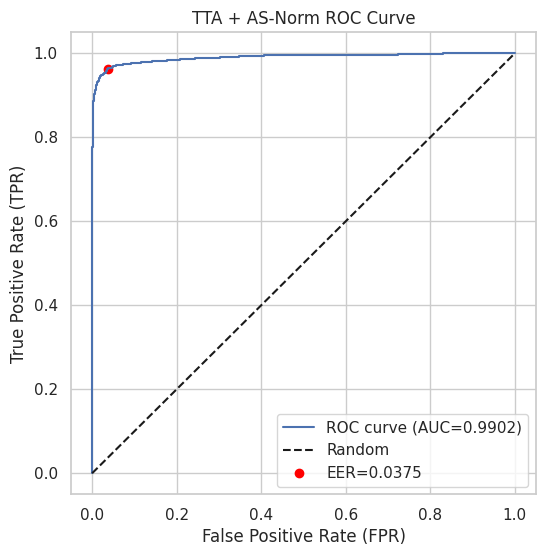

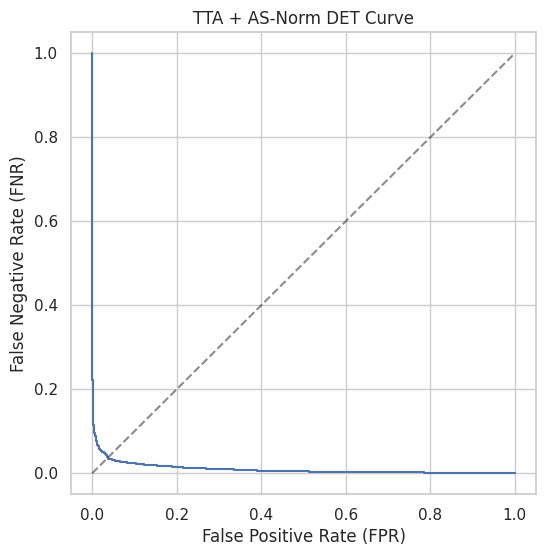

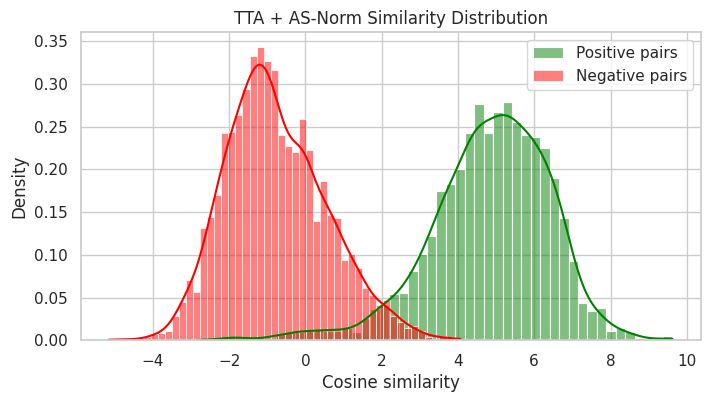

TTA + AS-Norm Summary:
EER: 0.0375, AUC: 0.9902
FPR @ FNR=0.01: 0.3030
FPR @ FNR=0.05: 0.0263
FPR @ FNR=0.10: 0.0050
FNR @ FPR=0.01: 0.0777
FNR @ FPR=0.05: 0.0323
FNR @ FPR=0.10: 0.0233


In [30]:
plot_verification_metrics(m_full, title_prefix="TTA + AS-Norm")

Dla podzbioru przynajmniej 500 próbek wykonaj losowo (z prawdopodobieństwem
jednostajnym) przemnożenia amplitudy próbki przez wartość ze zbioru {25, 1,
0.04}, a następnie porównaj skuteczność modelu z wynikami uzyskanymi w zadaniu 1.

In [32]:
scales = [25, 1, 0.04]
output_base = Path("/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2")
input_base = Path("/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k")

all_files = sorted({f for p in test_pairs for f in p[:2]})
print(f"Przetwarzamy {len(all_files)} unikalnych plików z test_pairs")

Przetwarzamy 4271 unikalnych plików z test_pairs


In [34]:
from tqdm import tqdm
import soundfile as sf

output_base.mkdir(parents=True, exist_ok=True)

for f in tqdm(all_files, desc="Scaling audio files"):
    audio, sr = sf.read(f)
    
    # Skaluje każdą próbkę audio losowo
    scale_factors = np.random.choice(scales, size=audio.shape)
    audio_scaled = audio * scale_factors
    
    # Wyciągnij speaker_id i nazwę pliku z oryginalnej ścieżki
    parts = Path(f).parts
    try:
        speaker_id = parts[-2]
        filename = parts[-1]
    except IndexError:
        raise ValueError(f"Nie można wydobyć speaker_id z pliku {f}")
    
    # Stwórz katalog docelowy
    output_dir = output_base / speaker_id
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Zapisz zmodyfikowane audio
    output_path = output_dir / filename
    sf.write(output_path, audio_scaled, sr)

print(f"Przetworzone pliki zapisano w {output_base}")

Scaling audio files: 100%|██████████| 4271/4271 [00:22<00:00, 190.68it/s]

Przetworzone pliki zapisano w /net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2


In [35]:
test_pairs_exp_2 = [
    (f1.replace('wav_16k', 'wav_16k_exp2'), f2.replace('wav_16k', 'wav_16k_exp2'), l)
    for f1, f2, l in test_pairs
]
test_pairs_exp_2[:2]

[('/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2/91f785d7f7db53be5abb2853ce11b4a0eb1dd376578bba1a659ffb61a88353b02691712a3820a15c94575a6280eb44fccccdabb5e83b20a90909fe96df767e0f/common_voice_pl_40024277.wav',
  '/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2/01f4a8ac304e5a92453296253fd0c3b0d876e6e6fd7bad18a05257da2703a7337e1cb77ad58697f3d1e7311561573beb4054fcc412d365ef3b0784ff28cf5939/common_voice_pl_20615471.wav',
  0),
 ('/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2/c298bc43c0bdc25fab49859ddb40ea34204302395ceac07aba08cd2e4e20542b316502bb52f7b2afac2b0955c964a7cd8b1f447a351c9a773d5091fdcef8dbfb/common_voice_pl_20646699.wav',
  '/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_exp2/c298bc43c0bdc25fab49859ddb40ea34204302395ceac07aba08cd2e4e20542b316502bb52f7b2afac2b0955c964a7cd8b1f447a351c9a773d5091fdcef8dbfb/common_voice_pl_20646634.wav',
  1)]

In [37]:
test_emb_tta_exp_2 = extract_embeddings(test_pairs_exp_2, num_crops=EVAL_NUM_CROPS)
m_full_exp_2 = compute_asnorm_metrics(test_pairs_exp_2, test_emb_tta_exp_2, cohort_embeddings, top_n=ASNORM_TOP_N)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [40]:
def compare_verification_metrics(metrics1, metrics2, label1="Original", label2="Scaled Audio"):
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set(style="whitegrid")
    
    # ===========================
    # ROC Curve
    # ===========================
    plt.figure(figsize=(6,6))
    plt.plot(metrics1["fpr"], metrics1["tpr"], label=f'{label1} (AUC={metrics1["auc"]:.4f})')
    plt.plot(metrics2["fpr"], metrics2["tpr"], label=f'{label2} (AUC={metrics2["auc"]:.4f})')
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===========================
    # DET Curve
    # ===========================
    plt.figure(figsize=(6,6))
    plt.plot(metrics1["fpr"], metrics1["fnr"], label=label1)
    plt.plot(metrics2["fpr"], metrics2["fnr"], label=label2)
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("False Negative Rate (FNR)")
    plt.title("DET Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ===========================
    # Histogram Similarities
    # ===========================
    plt.figure(figsize=(10,5))
    for sims, labels, lbl in [(metrics1["similarities"], metrics1["labels"], label1),
                              (metrics2["similarities"], metrics2["labels"], label2)]:
        sims_pos = sims[np.array(labels) == 1]
        sims_neg = sims[np.array(labels) == 0]
        sns.kdeplot(sims_pos, label=f'{lbl} Pos', fill=True, alpha=0.3)
        sns.kdeplot(sims_neg, label=f'{lbl} Neg', fill=True, alpha=0.3)
    plt.title("Similarity Distribution Comparison")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Density")
    plt.legend()
    plt.show()
    
    # ===========================
    # Print summary
    # ===========================
    print(f"{label1}: EER={metrics1['eer']:.4f}, AUC={metrics1['auc']:.4f}")
    print(f"{label2}: EER={metrics2['eer']:.4f}, AUC={metrics2['auc']:.4f}")

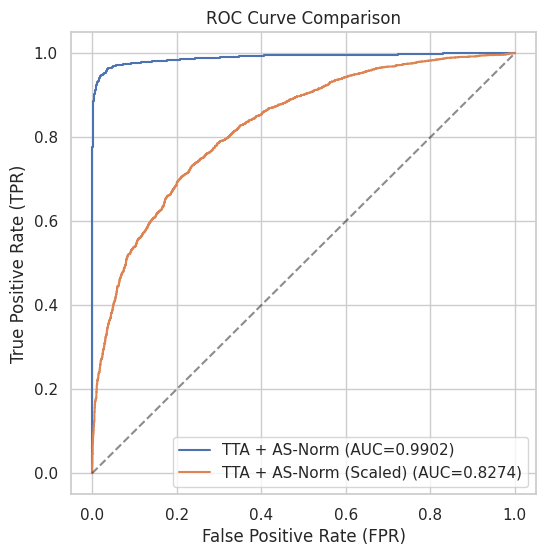

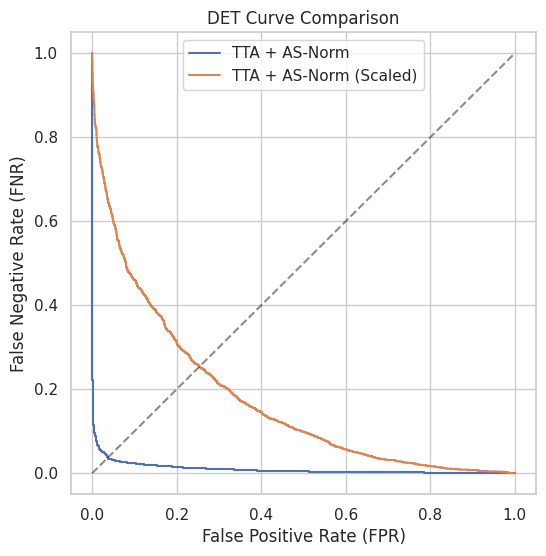

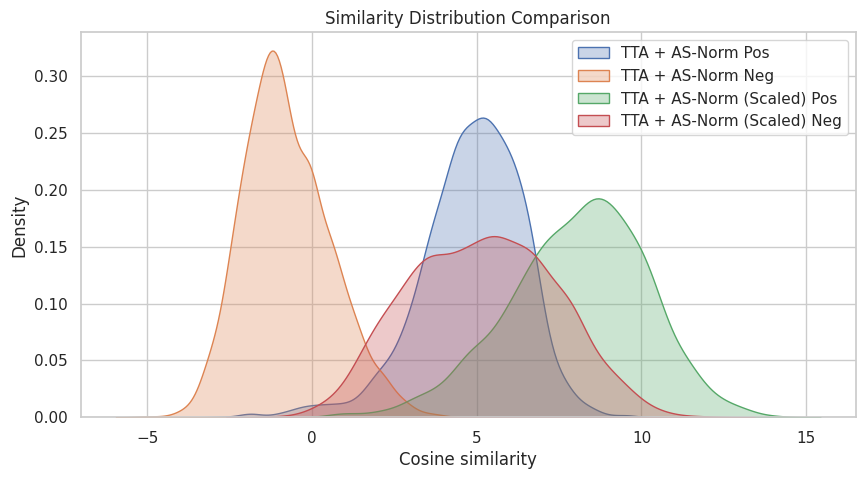

TTA + AS-Norm: EER=0.0375, AUC=0.9902
TTA + AS-Norm (Scaled): EER=0.2545, AUC=0.8274


In [41]:
compare_verification_metrics(m_full, m_full_exp_2, label1="TTA + AS-Norm", label2="TTA + AS-Norm (Scaled)")

 Dla wybranych 200 próbek sygnału zmniejsz częstotliwość próbkowania poprzez
naiwne pozostawienie co 2., co 5. oraz co 10. wartości (pamiętaj o metadanych).
Sprawdź, jak subsampling wpływa na wymaganą długość próbki sygnału oraz na
skuteczność uwierzytelniania. Następnie powtórz eksperyment (downsampling 2x,
5x i 10x) korzystając ze standardowych metod downsamplingu z interpolacją

In [42]:
downsample_factors = [2, 5, 10]
output_base_template = "/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_down{}"

for factor in downsample_factors:
    output_base = Path(output_base_template.format(factor))
    output_base.mkdir(parents=True, exist_ok=True)
    
    print(f"\nPrzetwarzanie downsampling factor={factor}")
    for f in tqdm(all_files, desc=f"Downsampling x{factor}"):
        # Wczytaj audio
        audio, sr = sf.read(f)
        
        # Downsampling: pozostaw co factor próbkę
        audio_down = audio[::factor]
        sr_down = sr // factor
        
        # Wyciągnij speaker_id i nazwę pliku
        parts = Path(f).parts
        speaker_id = parts[-2]
        filename = parts[-1]
        
        # Stwórz katalog docelowy
        output_dir = output_base / speaker_id
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Zapisz plik
        output_path = output_dir / filename
        sf.write(output_path, audio_down, sr_down)


Przetwarzanie downsampling factor=2


Downsampling x2: 100%|██████████| 4271/4271 [00:15<00:00, 278.16it/s]



Przetwarzanie downsampling factor=5


Downsampling x5: 100%|██████████| 4271/4271 [00:13<00:00, 309.55it/s]



Przetwarzanie downsampling factor=10


Downsampling x10: 100%|██████████| 4271/4271 [00:13<00:00, 324.34it/s]


In [43]:
test_pairs_down2 = [
    (f1.replace('wav_16k', 'wav_16k_down2'), f2.replace('wav_16k', 'wav_16k_down2'), l)
    for f1, f2, l in test_pairs
]
test_pairs_down5 = [
    (f1.replace('wav_16k', 'wav_16k_down5'), f2.replace('wav_16k', 'wav_16k_down5'), l)
    for f1, f2, l in test_pairs
]
test_pairs_down10 = [
    (f1.replace('wav_16k', 'wav_16k_down10'), f2.replace('wav_16k', 'wav_16k_down10'), l)
    for f1, f2, l in test_pairs
]

In [44]:
test_emb_tta_down_2 = extract_embeddings(test_pairs_down2, num_crops=EVAL_NUM_CROPS)
m_full_down_2 = compute_asnorm_metrics(test_pairs_down2, test_emb_tta_down_2, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_down_5 = extract_embeddings(test_pairs_down5, num_crops=EVAL_NUM_CROPS)
m_full_down_5 = compute_asnorm_metrics(test_pairs_down5, test_emb_tta_down_5, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_down_10 = extract_embeddings(test_pairs_down10, num_crops=EVAL_NUM_CROPS)
m_full_down_10 = compute_asnorm_metrics(test_pairs_down10, test_emb_tta_down_10, cohort_embeddings, top_n=ASNORM_TOP_N)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs

In [45]:
def compare_downsampling_metrics(metrics_orig, metrics_down_dict):
    """
    Porównanie oryginalnego modelu z kilkoma wariantami downsample.
    
    metrics_orig: dict z metrykami dla oryginalnego modelu
    metrics_down_dict: dict {factor: metrics}, np. {2: m_down2, 5: m_down5, 10: m_down10}
    """
    sns.set(style="whitegrid")
    
    # ===========================
    # ROC Curve – wszystkie na jednym wykresie
    # ===========================
    plt.figure(figsize=(7,7))
    plt.plot(metrics_orig["fpr"], metrics_orig["tpr"], label=f'Original (AUC={metrics_orig["auc"]:.4f})')
    for factor, m in metrics_down_dict.items():
        plt.plot(m["fpr"], m["tpr"], label=f'Downsample x{factor} (AUC={m["auc"]:.4f})')
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # ===========================
    # DET Curve – wszystkie na jednym wykresie
    # ===========================
    plt.figure(figsize=(7,7))
    plt.plot(metrics_orig["fpr"], metrics_orig["fnr"], label="Original")
    for factor, m in metrics_down_dict.items():
        plt.plot(m["fpr"], m["fnr"], label=f'Downsample x{factor}')
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("False Negative Rate (FNR)")
    plt.title("DET Curve Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # ===========================
    # Histogram Similarities – osobny wykres dla każdego downsample
    # ===========================
    for factor, m in metrics_down_dict.items():
        plt.figure(figsize=(10,5))
        for sims, labels, lbl in [
            (metrics_orig["similarities"], metrics_orig["labels"], "Original"),
            (m["similarities"], m["labels"], f"Downsample x{factor}")
        ]:
            sims_pos = sims[np.array(labels) == 1]
            sims_neg = sims[np.array(labels) == 0]
            sns.kdeplot(sims_pos, label=f'{lbl} Pos', fill=True, alpha=0.3)
            sns.kdeplot(sims_neg, label=f'{lbl} Neg', fill=True, alpha=0.3)
        plt.title(f"Similarity Distribution Comparison – Downsample x{factor}")
        plt.xlabel("Cosine similarity")
        plt.ylabel("Density")
        plt.legend()
        plt.show()
        
        # Print summary
        print(f"Original: EER={metrics_orig['eer']:.4f}, AUC={metrics_orig['auc']:.4f}")
        print(f"Downsample x{factor}: EER={m['eer']:.4f}, AUC={m['auc']:.4f}")
        print("-"*50)

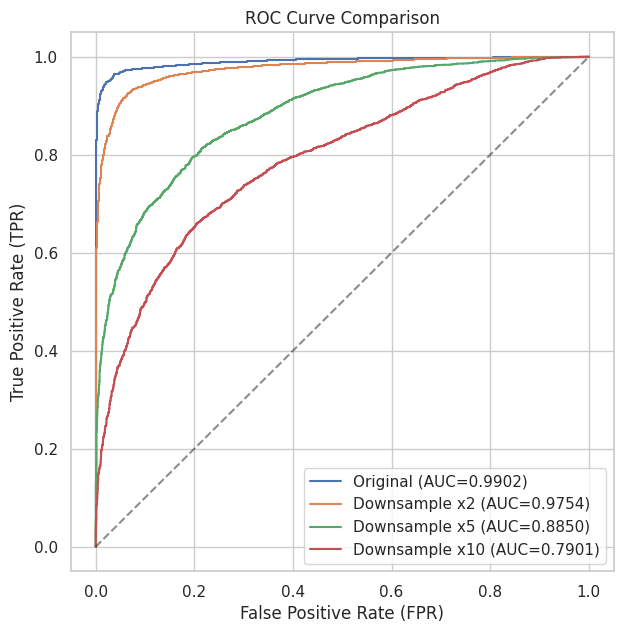

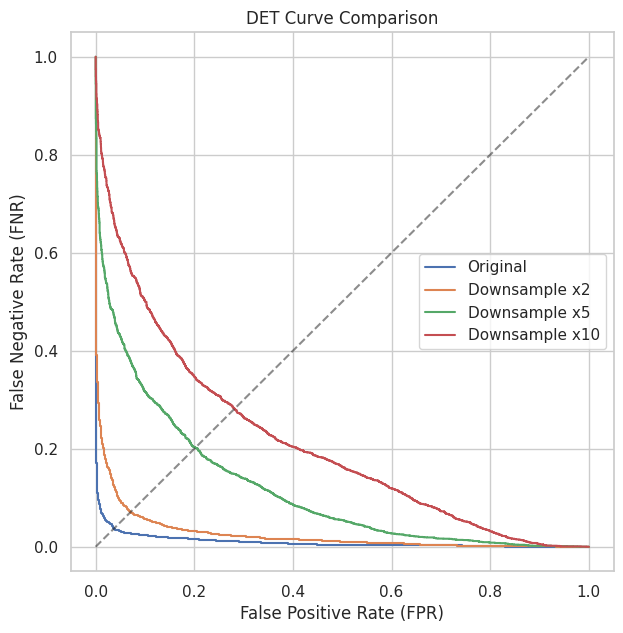

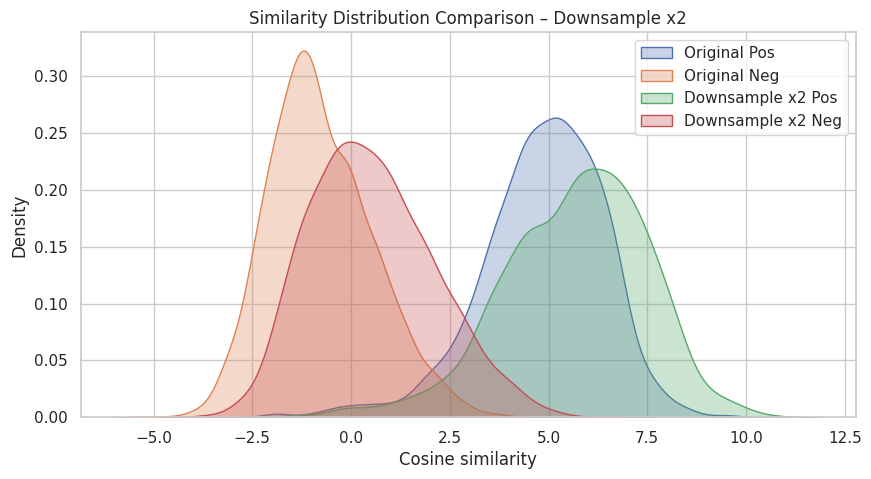

Original: EER=0.0375, AUC=0.9902
Downsample x2: EER=0.0717, AUC=0.9754
--------------------------------------------------


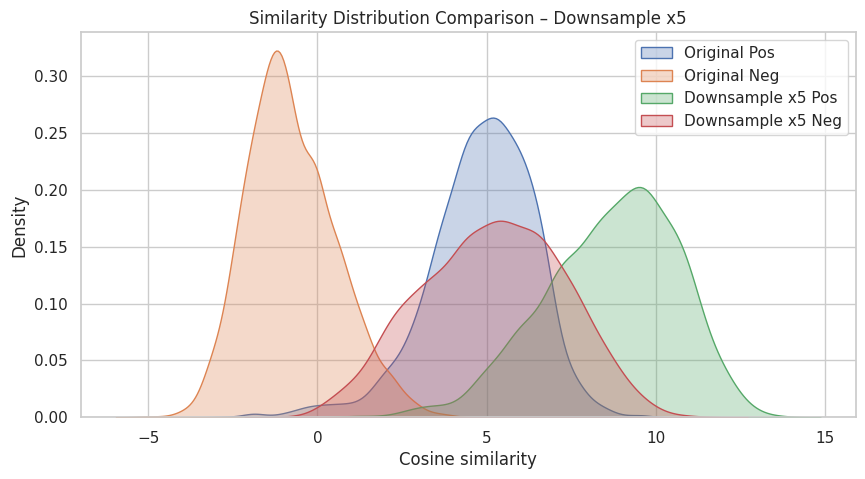

Original: EER=0.0375, AUC=0.9902
Downsample x5: EER=0.2022, AUC=0.8850
--------------------------------------------------


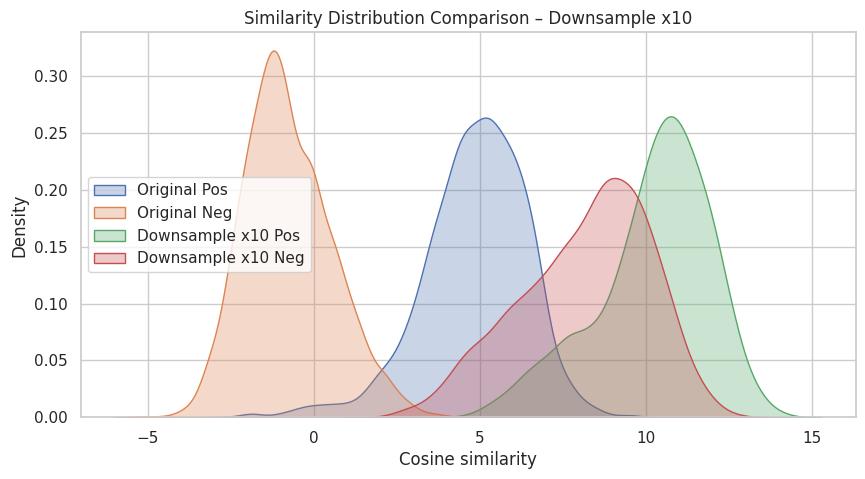

Original: EER=0.0375, AUC=0.9902
Downsample x10: EER=0.2820, AUC=0.7901
--------------------------------------------------


In [47]:
metrics_down_dict = {
    2: m_full_down_2,
    5: m_full_down_5,
    10: m_full_down_10
}

compare_downsampling_metrics(m_full, metrics_down_dict)

In [49]:
crop_lengths = [2, 4, 8]

down_2_results = []
down_5_results = []
down_10_results = []

for crop_sec in crop_lengths:
    
    emb = extract_embeddings(test_pairs_down2, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_down2, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    down_2_results.append(time_metrics)

    emb = extract_embeddings(test_pairs_down5, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_down5, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    down_5_results.append(time_metrics)

    emb = extract_embeddings(test_pairs_down10, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_down10, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    down_10_results.append(time_metrics)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs

In [50]:
def plot_summary(crop_lengths,
                 down_2_results,
                 down_5_results,
                 down_10_results):

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # EER
    ax[0].plot(crop_lengths, [m["eer"] for m in down_2_results], marker="o", label="x2")
    ax[0].plot(crop_lengths, [m["eer"] for m in down_5_results], marker="o", label="x5")
    ax[0].plot(crop_lengths, [m["eer"] for m in down_10_results], marker="o", label="x10")
    ax[0].set_title("EER vs crop length")
    ax[0].set_xlabel("Seconds")
    ax[0].set_ylabel("EER (↓)")
    ax[0].grid(True)
    ax[0].legend()

    # AUC
    ax[1].plot(crop_lengths, [m["auc"] for m in down_2_results], marker="o", label="x2")
    ax[1].plot(crop_lengths, [m["auc"] for m in down_5_results], marker="o", label="x5")
    ax[1].plot(crop_lengths, [m["auc"] for m in down_10_results], marker="o", label="x10")
    ax[1].set_title("AUC vs crop length")
    ax[1].set_xlabel("Seconds")
    ax[1].set_ylabel("AUC (↑)")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

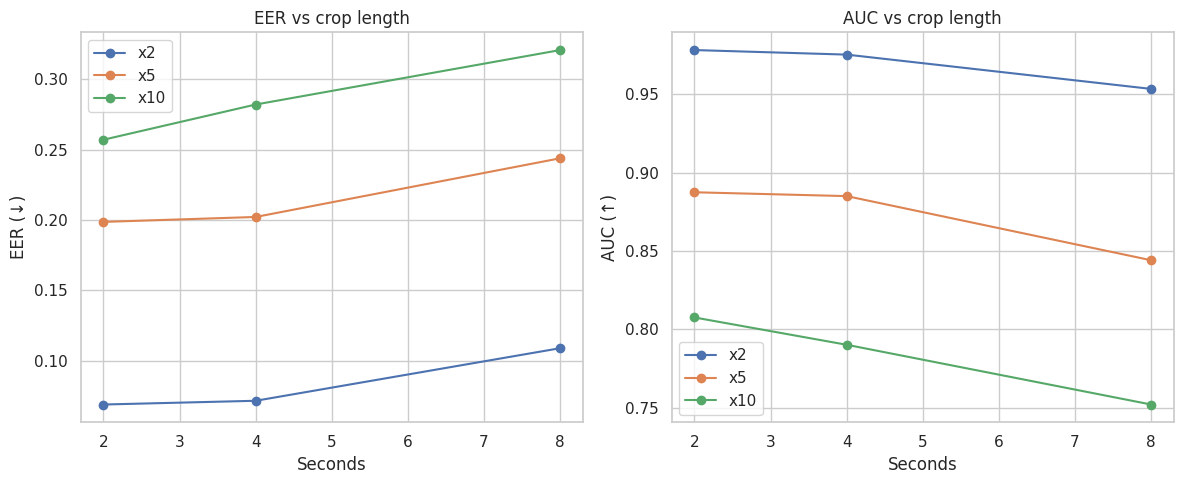

In [51]:
plot_summary(
    crop_lengths,
    down_2_results,
    down_5_results,
    down_10_results
)

In [52]:
from scipy.signal import decimate

downsample_factors = [2, 5, 10]
output_base_template = "/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_scipy_down{}"

for factor in downsample_factors:
    output_base = Path(output_base_template.format(factor))
    output_base.mkdir(parents=True, exist_ok=True)
    
    print(f"\nPrzetwarzanie downsampling factor={factor}")
    for f in tqdm(all_files, desc=f"Downsampling x{factor}"):
        # Wczytaj audio
        audio, sr = sf.read(f)
        
        # Downsampling
        audio_down = decimate(audio, factor, ftype='iir', zero_phase=True, axis=0)
        sr_down = sr // factor
        
        # Wyciągnij speaker_id i nazwę pliku
        parts = Path(f).parts
        speaker_id = parts[-2]
        filename = parts[-1]
        
        # Stwórz katalog docelowy
        output_dir = output_base / speaker_id
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Zapisz plik
        output_path = output_dir / filename
        sf.write(output_path, audio_down, sr_down)


Przetwarzanie downsampling factor=2


Downsampling x2: 100%|██████████| 4271/4271 [00:29<00:00, 144.13it/s]



Przetwarzanie downsampling factor=5


Downsampling x5: 100%|██████████| 4271/4271 [00:26<00:00, 163.08it/s]



Przetwarzanie downsampling factor=10


Downsampling x10: 100%|██████████| 4271/4271 [00:25<00:00, 169.38it/s]


In [53]:
test_pairs_scipy_down2 = [
    (f1.replace('wav_16k', 'wav_16k_scipy_down2'), f2.replace('wav_16k', 'wav_16k_scipy_down2'), l)
    for f1, f2, l in test_pairs
]
test_pairs_scipy_down5 = [
    (f1.replace('wav_16k', 'wav_16k_scipy_down5'), f2.replace('wav_16k', 'wav_16k_scipy_down5'), l)
    for f1, f2, l in test_pairs
]
test_pairs_scipy_down10 = [
    (f1.replace('wav_16k', 'wav_16k_scipy_down10'), f2.replace('wav_16k', 'wav_16k_scipy_down10'), l)
    for f1, f2, l in test_pairs
]

In [54]:
test_emb_tta_scipy_down_2 = extract_embeddings(test_pairs_scipy_down2, num_crops=EVAL_NUM_CROPS)
m_full_scipy_down_2 = compute_asnorm_metrics(test_pairs_scipy_down2, test_emb_tta_scipy_down_2, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_scipy_down_5 = extract_embeddings(test_pairs_scipy_down5, num_crops=EVAL_NUM_CROPS)
m_full_scipy_down_5 = compute_asnorm_metrics(test_pairs_scipy_down5, test_emb_tta_scipy_down_5, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_scipy_down_10 = extract_embeddings(test_pairs_scipy_down10, num_crops=EVAL_NUM_CROPS)
m_full_scipy_down_10 = compute_asnorm_metrics(test_pairs_scipy_down10, test_emb_tta_scipy_down_10, cohort_embeddings, top_n=ASNORM_TOP_N)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs

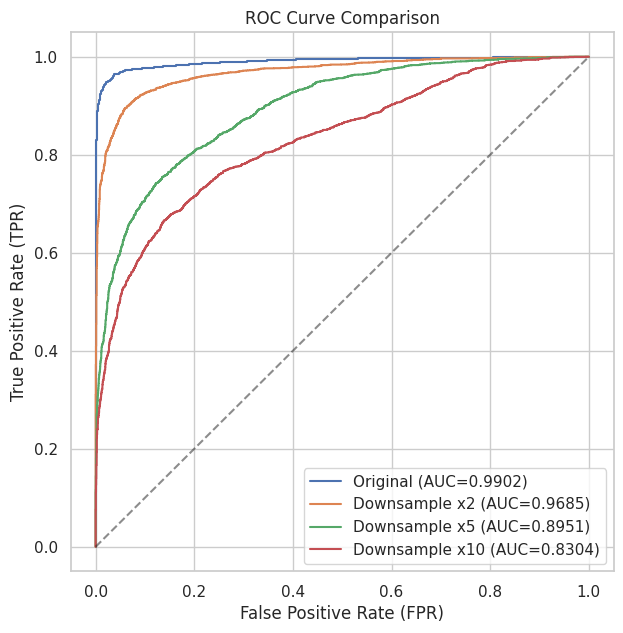

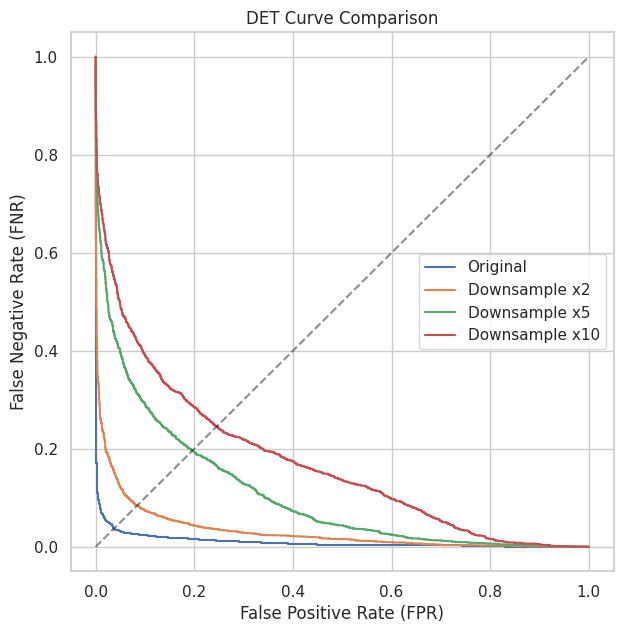

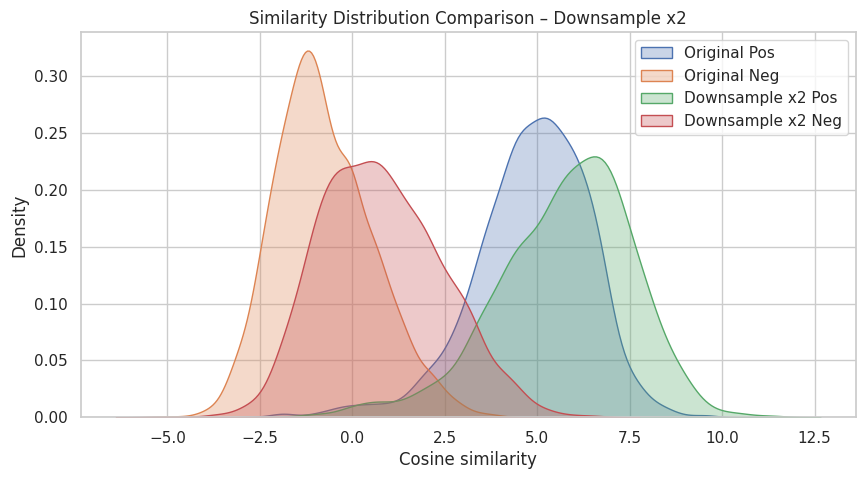

Original: EER=0.0375, AUC=0.9902
Downsample x2: EER=0.0845, AUC=0.9685
--------------------------------------------------


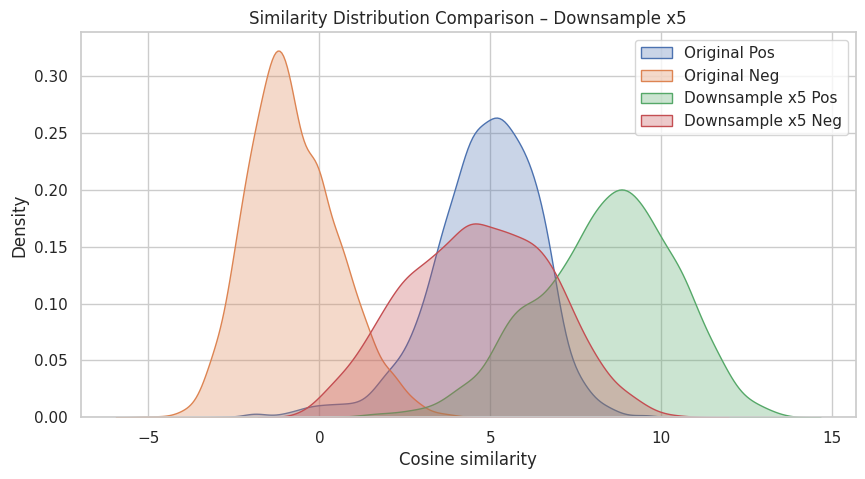

Original: EER=0.0375, AUC=0.9902
Downsample x5: EER=0.1965, AUC=0.8951
--------------------------------------------------


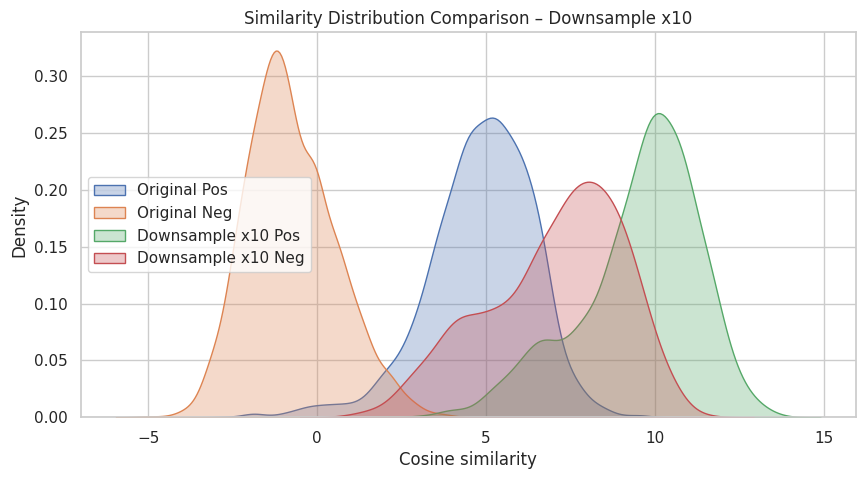

Original: EER=0.0375, AUC=0.9902
Downsample x10: EER=0.2457, AUC=0.8304
--------------------------------------------------


In [55]:
metrics_scipy_down_dict = {
    2: m_full_scipy_down_2,
    5: m_full_scipy_down_5,
    10: m_full_scipy_down_10
}

compare_downsampling_metrics(m_full, metrics_scipy_down_dict)

In [66]:
scipy_down_2_results = down_2_results[3:]
scipy_down_5_results = down_5_results[3:]
scipy_down_10_results = down_10_results[3:]

In [56]:
crop_lengths = [2, 4, 8]

scipy_down_2_results = []
scipy_down_5_results = []
scipy_down_10_results = []

for crop_sec in crop_lengths:
    
    emb = extract_embeddings(test_pairs_scipy_down2, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_scipy_down2, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    scipy_down_2_results.append(time_metrics)

    emb = extract_embeddings(test_pairs_scipy_down5, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_scipy_down5, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    scipy_down_5_results.append(time_metrics)

    emb = extract_embeddings(test_pairs_scipy_down10, num_crops=EVAL_NUM_CROPS, crop_seconds=crop_sec)
    time_metrics = compute_asnorm_metrics(test_pairs_scipy_down10, emb, cohort_embeddings, top_n=ASNORM_TOP_N)
    scipy_down_10_results.append(time_metrics)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs

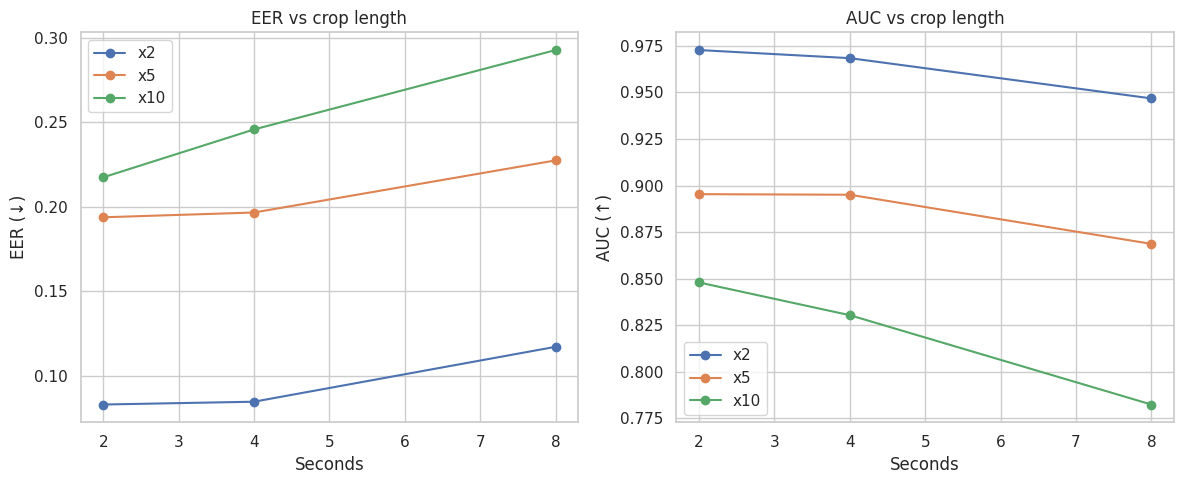

In [69]:
plot_summary(
    crop_lengths,
    scipy_down_2_results,
    scipy_down_5_results,
    scipy_down_10_results
)

Dla 100 próbek dodaj addytywny szum Gaussowski i przetestuj działanie systemu
dla kilku poziomów SNR, np. 40 dB, 20 dB oraz 10 dB. Szum należy dobrać
tak, aby dla każdej próbki uzyskać zadany poziom SNR względem oryginalnego
sygnału. Następnie zbadaj skuteczność systemu i porównaj wyniki z wynikami
uzyskanymi w zadaniu 1

In [70]:
def add_awgn(signal, snr_db):
    """
    Dodaje biały szum Gaussowski do sygnału, aby osiągnąć zadany SNR (dB)
    
    Parameters:
        signal : np.array
            Oryginalny sygnał audio
        snr_db : float
            Pożądany stosunek sygnału do szumu w decybelach
    
    Returns:
        noisy_signal : np.array
            Sygnał zaszumiony
    """
    # Moc sygnału
    power_signal = np.mean(signal**2)
    
    # Moc szumu potrzebna do osiągnięcia SNR
    snr_linear = 10**(snr_db / 10)
    power_noise = power_signal / snr_linear
    
    # Szum Gaussowski
    noise = np.random.normal(0, np.sqrt(power_noise), size=signal.shape)
    
    # Dodanie szumu
    noisy_signal = signal + noise
    return noisy_signal

In [71]:
snr_levels = [40, 20, 10]
output_template = "/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k_noisy_{}"

for snr in snr_levels:
    output_base = Path(output_template.format(snr))
    output_base.mkdir(parents=True, exist_ok=True)

    print(f"\nGenerating SNR={snr} dB dataset")

    for f in tqdm(all_files, desc=f"SNR {snr}"):
        audio, sr = sf.read(f)

        audio_noisy = add_awgn(audio, snr)

        parts = Path(f).parts
        speaker_id = parts[-2]
        filename = parts[-1]

        out_dir = output_base / speaker_id
        out_dir.mkdir(parents=True, exist_ok=True)

        sf.write(out_dir / filename, audio_noisy, sr)


Generating SNR=40 dB dataset


SNR 40: 100%|██████████| 4271/4271 [00:27<00:00, 154.78it/s]



Generating SNR=20 dB dataset


SNR 20: 100%|██████████| 4271/4271 [00:26<00:00, 160.06it/s]



Generating SNR=10 dB dataset


SNR 10: 100%|██████████| 4271/4271 [00:26<00:00, 158.34it/s]


In [72]:
test_pairs_noise_40 = [
    (f1.replace('wav_16k', 'wav_16k_noisy_40'), f2.replace('wav_16k', 'wav_16k_noisy_40'), l)
    for f1, f2, l in test_pairs
]
test_pairs_noise_20 = [
    (f1.replace('wav_16k', 'wav_16k_noisy_20'), f2.replace('wav_16k', 'wav_16k_noisy_20'), l)
    for f1, f2, l in test_pairs
]
test_pairs_noise_10 = [
    (f1.replace('wav_16k', 'wav_16k_noisy_10'), f2.replace('wav_16k', 'wav_16k_noisy_10'), l)
    for f1, f2, l in test_pairs
]

In [73]:
test_emb_tta_noise_40 = extract_embeddings(test_pairs_noise_40, num_crops=EVAL_NUM_CROPS)
m_full_noise_40 = compute_asnorm_metrics(test_pairs_noise_40, test_emb_tta_noise_40, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_noise_20 = extract_embeddings(test_pairs_noise_20, num_crops=EVAL_NUM_CROPS)
m_full_noise_20 = compute_asnorm_metrics(test_pairs_noise_20, test_emb_tta_noise_20, cohort_embeddings, top_n=ASNORM_TOP_N)

test_emb_tta_noise_10 = extract_embeddings(test_pairs_noise_10, num_crops=EVAL_NUM_CROPS)
m_full_noise_10 = compute_asnorm_metrics(test_pairs_noise_10, test_emb_tta_noise_10, cohort_embeddings, top_n=ASNORM_TOP_N)

/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/net/pr2/projects/plgrid/plggdermatoai/test-venv2/lib64/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs

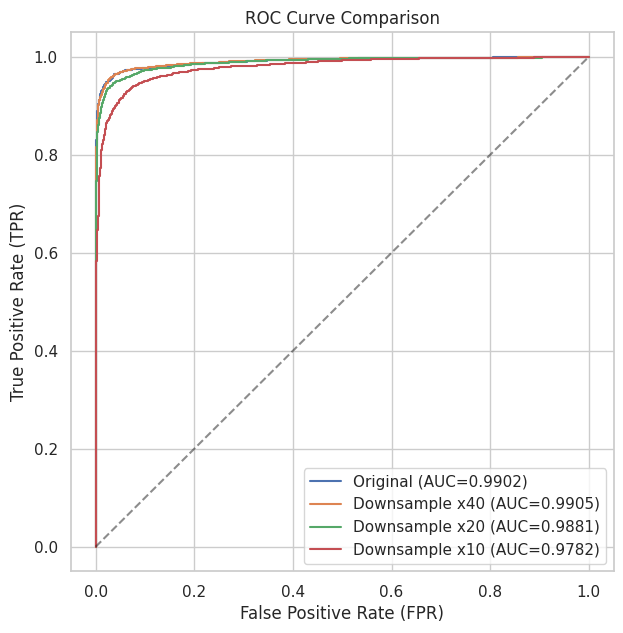

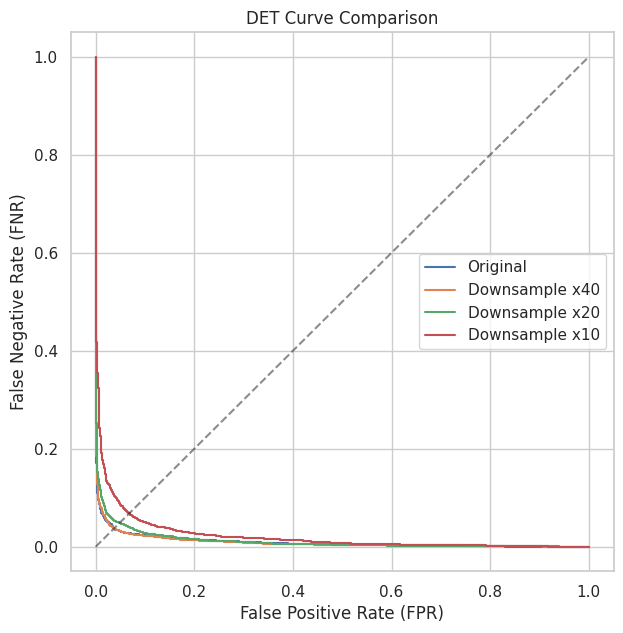

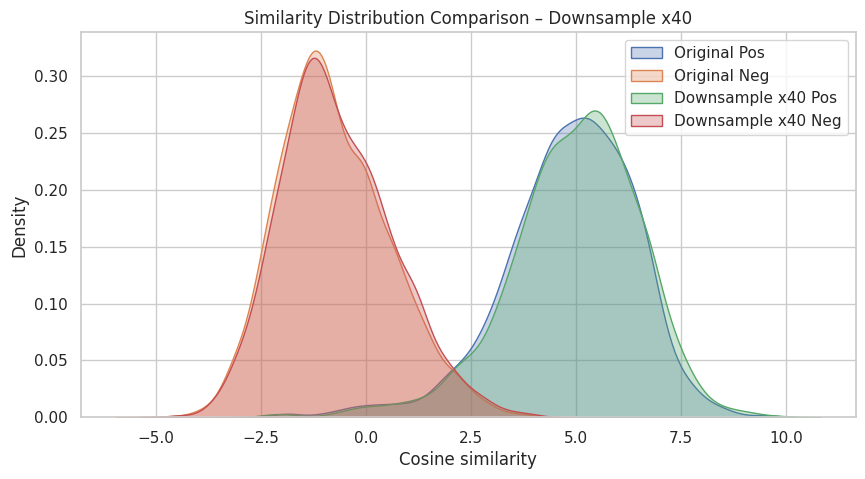

Original: EER=0.0375, AUC=0.9902
Downsample x40: EER=0.0373, AUC=0.9905
--------------------------------------------------


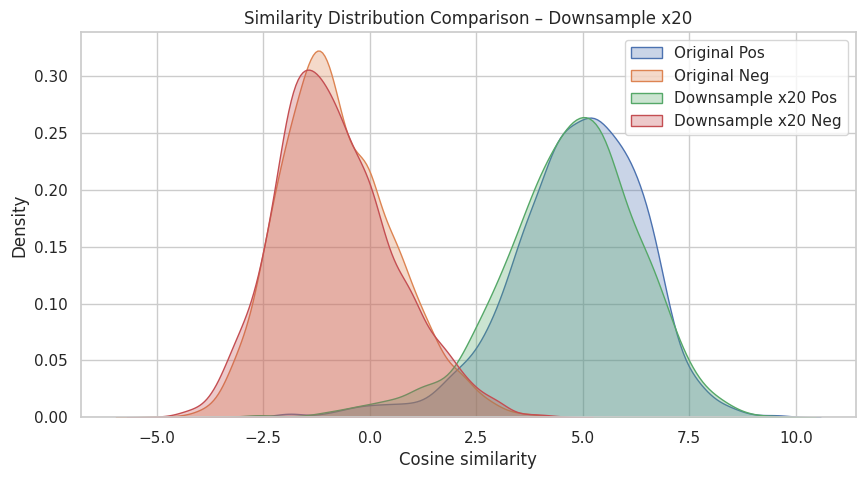

Original: EER=0.0375, AUC=0.9902
Downsample x20: EER=0.0492, AUC=0.9881
--------------------------------------------------


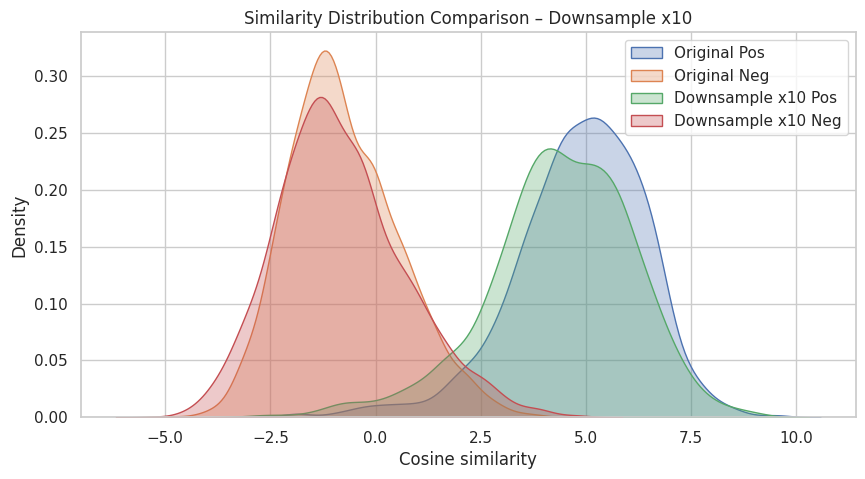

Original: EER=0.0375, AUC=0.9902
Downsample x10: EER=0.0687, AUC=0.9782
--------------------------------------------------


In [74]:
metrics_noise_dict = {
    40: m_full_noise_40,
    20: m_full_noise_20,
    10: m_full_noise_10
}

compare_downsampling_metrics(m_full, metrics_noise_dict)

# Display waves

In [36]:
import soundfile as sf

In [41]:
example_files = [
    'ffff45affaf3eac1f972d3337d5281fb3f0f13e7cee37aabd2a223619ecb59dec3d3807d692ca1e34b406dd680249cd00d92d2fa7c206db22bbd3d8aefe1f56d/common_voice_pl_37239050.wav',
    'ff1b6bdebbf3cc16e55b0a50efc1f825f700becff7cb114375b0cc8aa01731bebb701538938ffe0880237a4b48b88b72f57d271d29e42b4f97bf7846de2c6b8a/common_voice_pl_22087578.wav',
    'fdce3991efc705045e99a70330b0ea27949cb491d9870aef7ba9944b6384f7e732777d365b48227ebc42d17195e5fe859a96d94b059e2dd988ded8314ff149bb/common_voice_pl_20753223.wav',
]
example_files = [f"/net/tscratch/people/plgmarcintkocz/biometrics/biometrics2/wav_16k/{f}" for f in example_files]

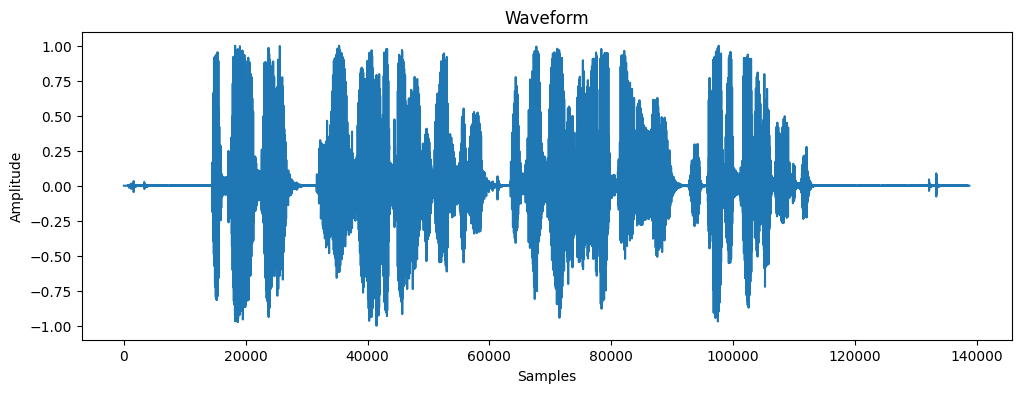

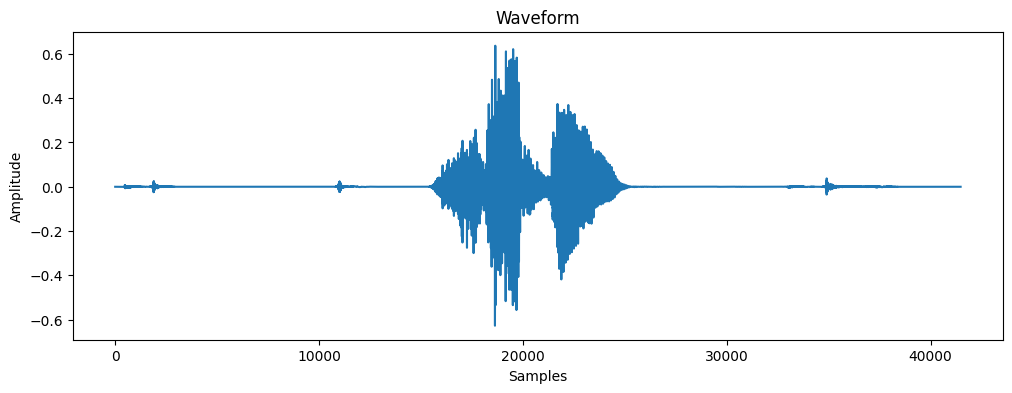

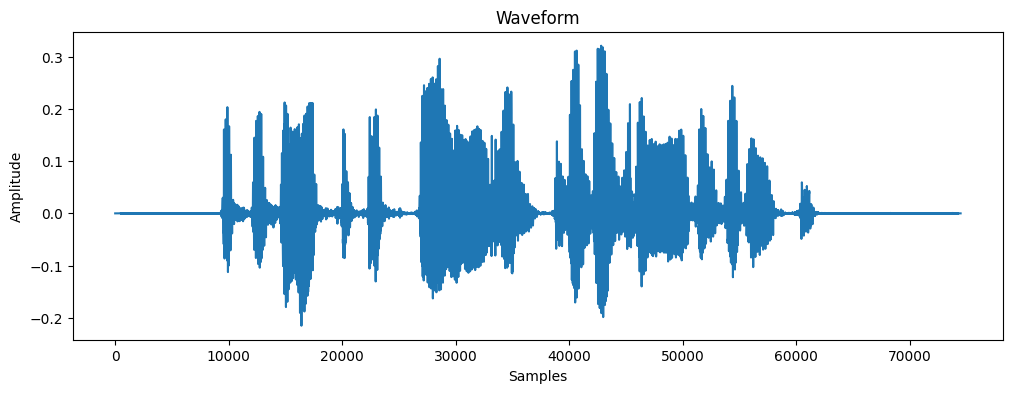

In [42]:
for f in example_files:
    audio, sr = sf.read(f)
    
    plt.figure(figsize=(12, 4))
    plt.plot(audio)
    plt.title("Waveform")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

wykonaj losowo (z prawdopodobieństwem jednostajnym) przemnożenia amplitudy próbki przez wartość ze zbioru {25, 1, 0.04}

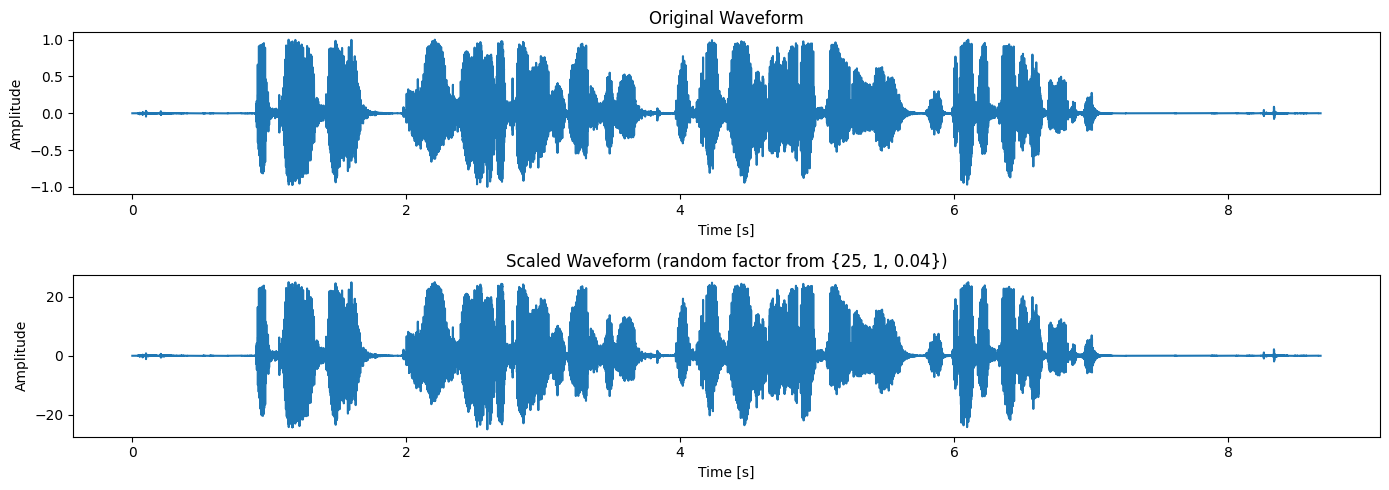

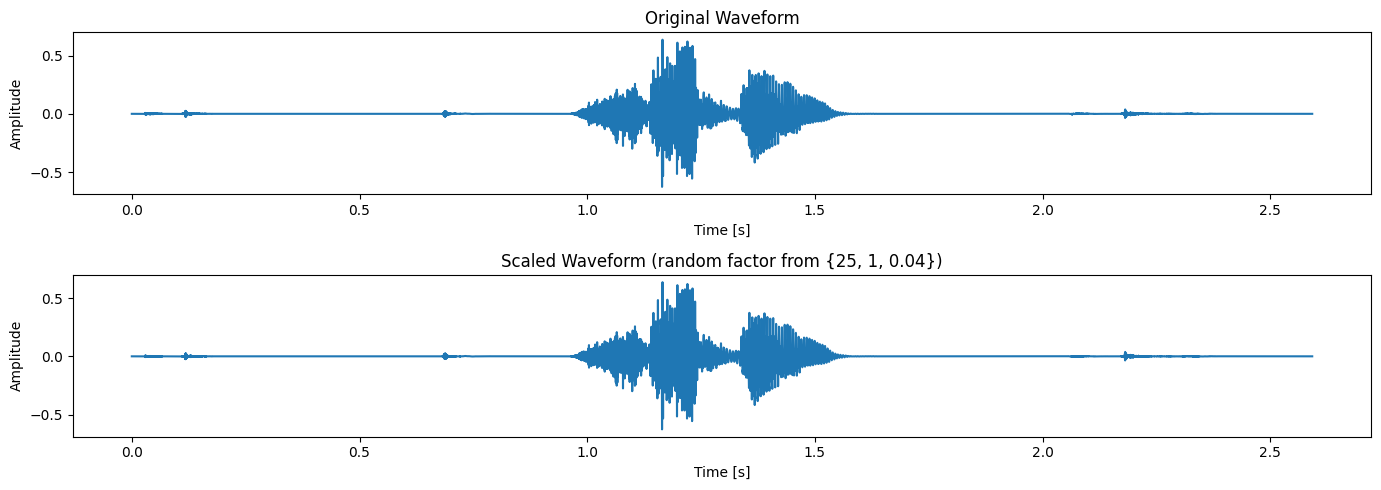

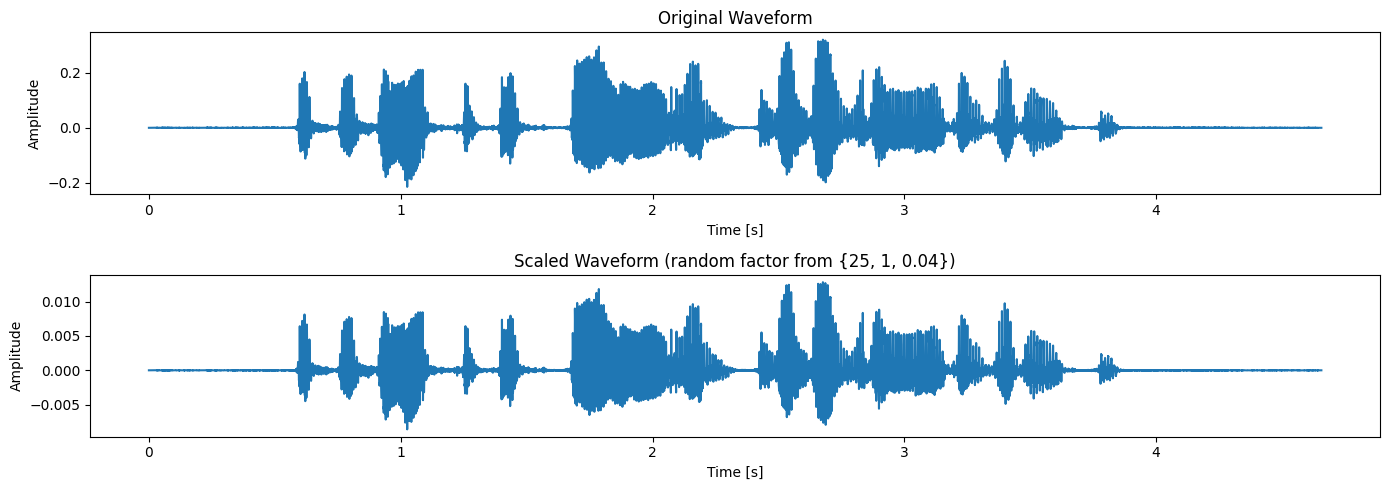

In [44]:
# The set of scaling factors
scales = [25, 1, 0.04]

for f in example_files:
    # Load audio
    audio, sr = sf.read(f)
    
    # Randomly choose a scale for each sample
    # # np.random.choice selects a value from scales for each element in audio
    scale_factors = np.random.choice(scales, size=audio.shape)
    
    # Apply the scaling
    audio_scaled = audio * scale_factors

    # Time axis for plotting
    time = np.linspace(0, len(audio) / sr, num=len(audio))
    
    # Plot before and after
    plt.figure(figsize=(14, 5))
    
    plt.subplot(2, 1, 1)
    plt.plot(time, audio)
    plt.title("Original Waveform")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    
    plt.subplot(2, 1, 2)
    plt.plot(time, audio_scaled)
    plt.title("Scaled Waveform (random factor from {25, 1, 0.04})")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()

zmniejsz częstotliwość próbkowania poprzez naiwne pozostawienie co 2., co 5. oraz co 10. wartości (pamiętaj o metadanych)

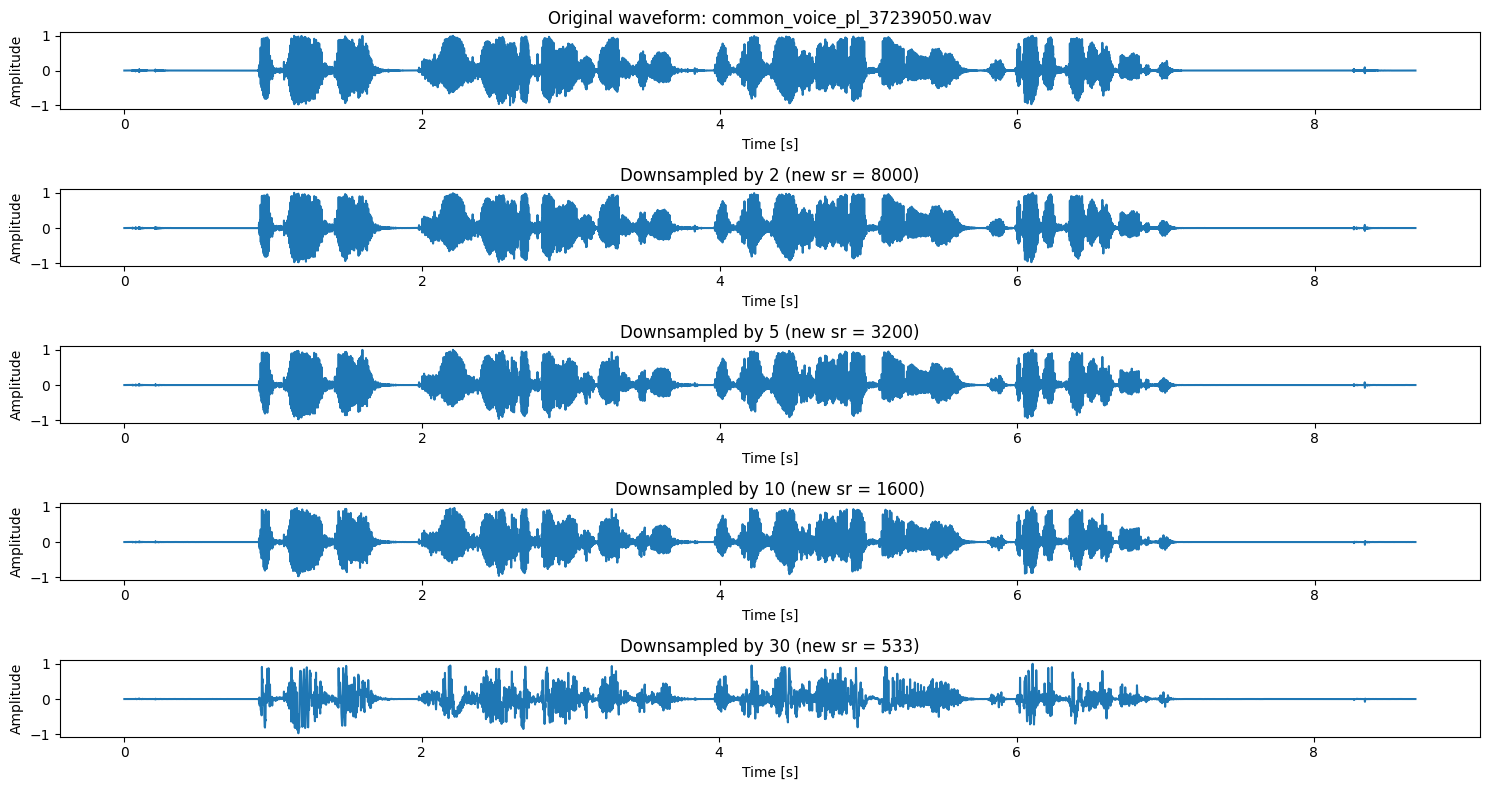

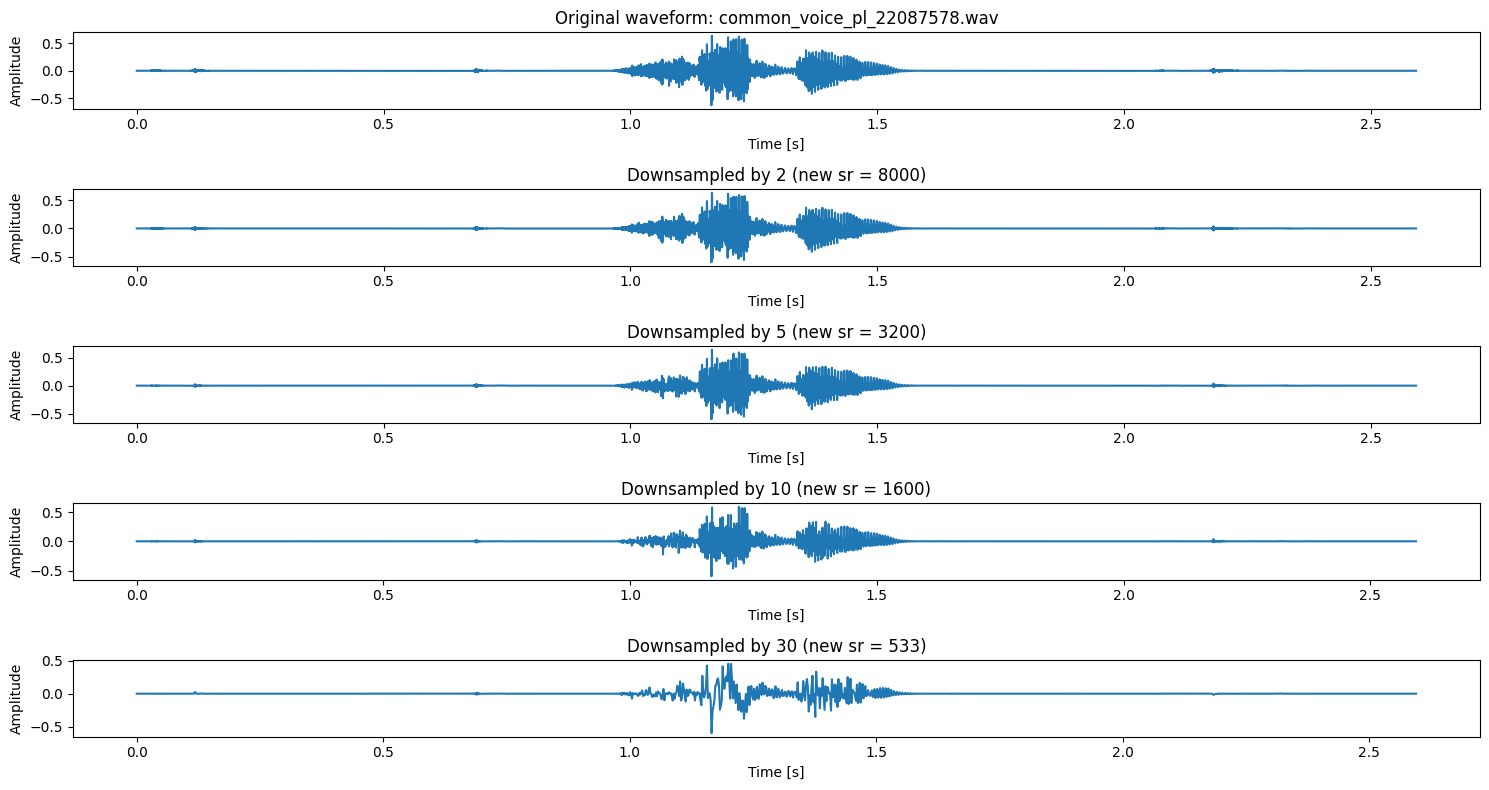

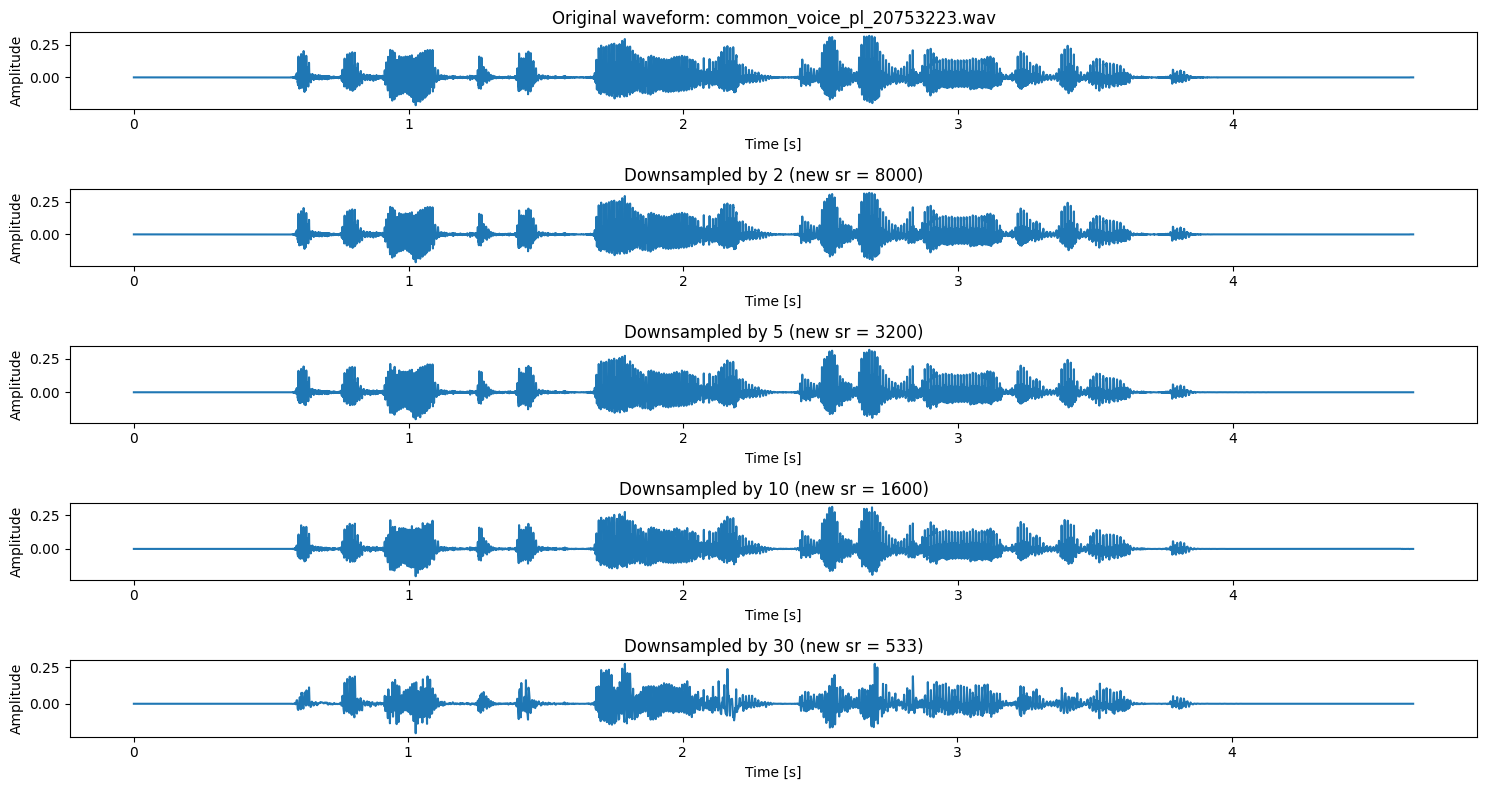

In [46]:
downsample_factors = [2, 5, 10]

for f in example_files:
    # Load original audio
    audio, sr = sf.read(f)
    
    plt.figure(figsize=(15, 8))
    
    # Original waveform
    time_orig = np.linspace(0, len(audio) / sr, num=len(audio))
    plt.subplot(len(downsample_factors)+1, 1, 1)
    plt.plot(time_orig, audio)
    plt.title(f"Original waveform: {f.split('/')[-1]}")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    
    # Downsample and plot
    for i, factor in enumerate(downsample_factors, start=2):
        audio_down = audio[::factor]          # keep every N-th sample
        sr_down = sr // factor                 # adjust sampling rate
        
        time_down = np.linspace(0, len(audio_down)/sr_down, num=len(audio_down))
        plt.subplot(len(downsample_factors)+1, 1, i)
        plt.plot(time_down, audio_down)
        plt.title(f"Downsampled by {factor} (new sr = {sr_down})")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()
    
    # Optional: save downsampled versions
    for factor in downsample_factors:
        audio_down = audio[::factor]
        sr_down = sr // factor
        out_file = f"{f.split('/')[-1].replace('.wav','')}_down{factor}.wav"
        sf.write(out_file, audio_down, sr_down)

 powtórz eksperyment (downsampling 2x,
5x i 10x) korzystając ze standardowych metod downsamplingu z interpolacją.

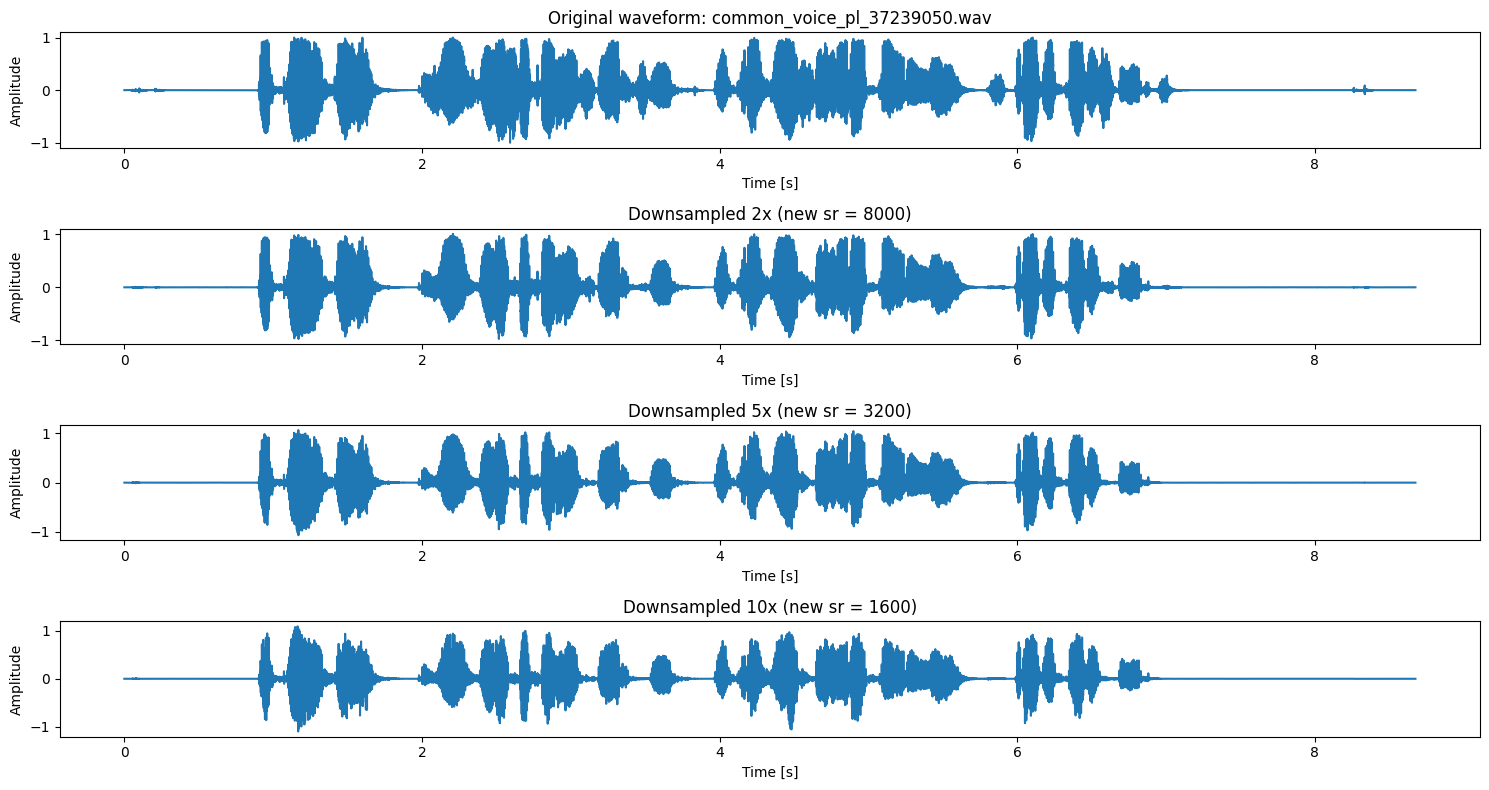

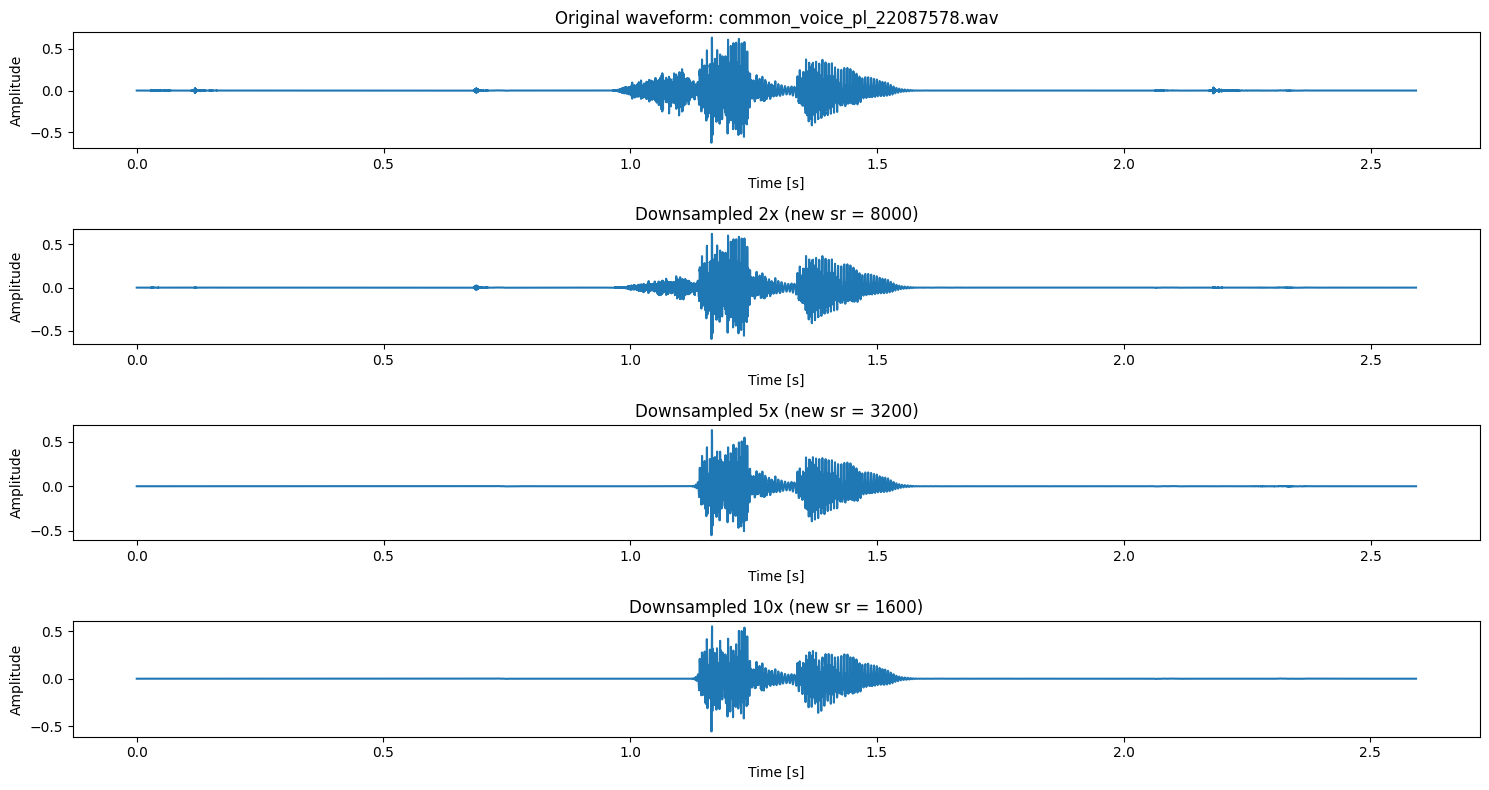

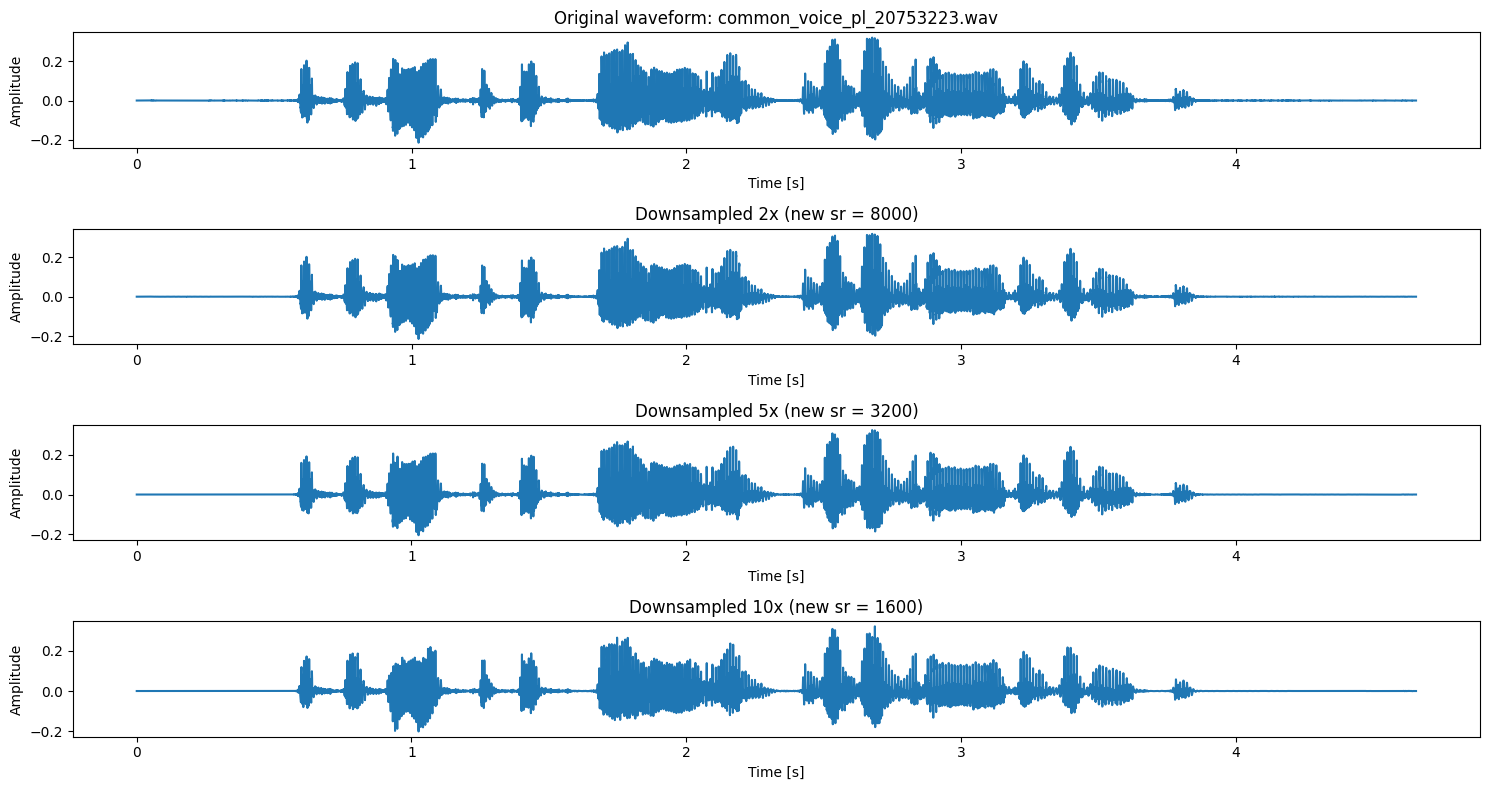

In [47]:
from scipy.signal import decimate

downsample_factors = [2, 5, 10]

for f in example_files:
    # Wczytanie oryginalnego audio
    audio, sr = sf.read(f)
    
    plt.figure(figsize=(15, 8))
    
    # Oryginalna fala
    time_orig = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.subplot(len(downsample_factors)+1, 1, 1)
    plt.plot(time_orig, audio)
    plt.title(f"Original waveform: {f.split('/')[-1]}")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    
    # Downsampling z interpolacją / filtrem antyaliasingowym
    for i, factor in enumerate(downsample_factors, start=2):
        # decimate obsługuje mono i stereo (axis=0)
        audio_down = decimate(audio, factor, ftype='iir', zero_phase=True, axis=0)
        sr_down = sr // factor
        
        time_down = np.linspace(0, len(audio_down)/sr_down, num=len(audio_down))
        plt.subplot(len(downsample_factors)+1, 1, i)
        plt.plot(time_down, audio_down)
        plt.title(f"Downsampled {factor}x (new sr = {sr_down})")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
    
    plt.tight_layout()
    plt.show()
    
    # # Opcjonalnie zapis
    # for factor in downsample_factors:
    #     audio_down = decimate(audio, factor, ftype='iir', zero_phase=True, axis=0)
    #     sr_down = sr // factor
    #     out_file = f"{f.split('/')[-1].replace('.wav','')}_down{factor}_interp.wav"
    #     sf.write(out_file, audio_down, sr_down)

dodaj addytywny szum Gaussowski

In [48]:
def add_awgn(signal, snr_db):
    """
    Dodaje biały szum Gaussowski do sygnału, aby osiągnąć zadany SNR (dB)
    
    Parameters:
        signal : np.array
            Oryginalny sygnał audio
        snr_db : float
            Pożądany stosunek sygnału do szumu w decybelach
    
    Returns:
        noisy_signal : np.array
            Sygnał zaszumiony
    """
    # Moc sygnału
    power_signal = np.mean(signal**2)
    
    # Moc szumu potrzebna do osiągnięcia SNR
    snr_linear = 10**(snr_db / 10)
    power_noise = power_signal / snr_linear
    
    # Szum Gaussowski
    noise = np.random.normal(0, np.sqrt(power_noise), size=signal.shape)
    
    # Dodanie szumu
    noisy_signal = signal + noise
    return noisy_signal

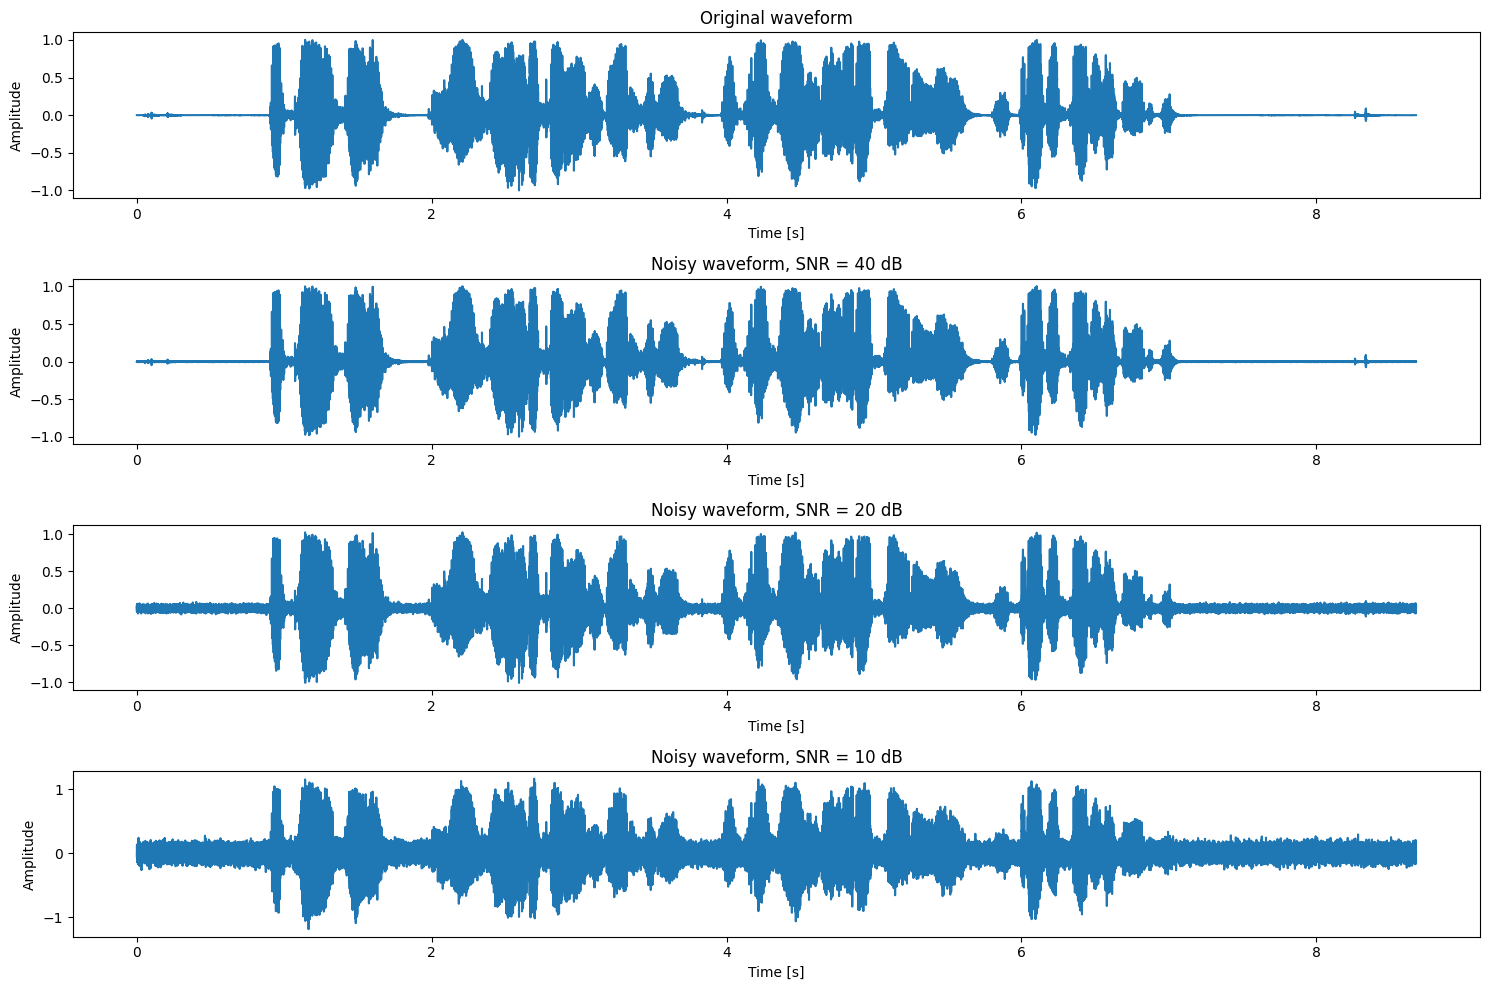

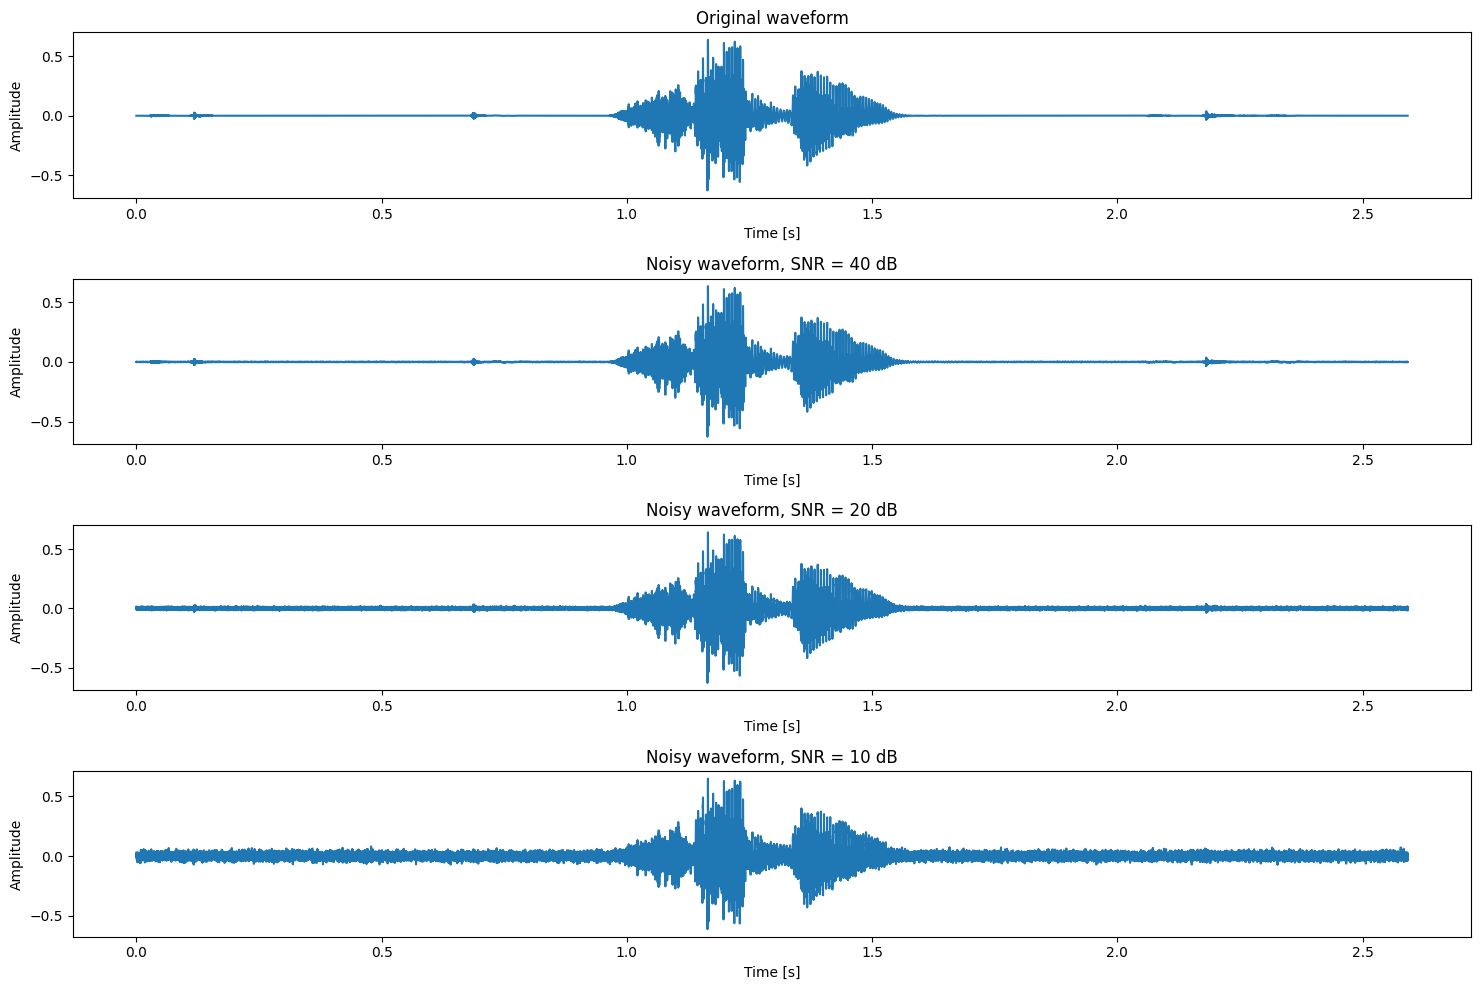

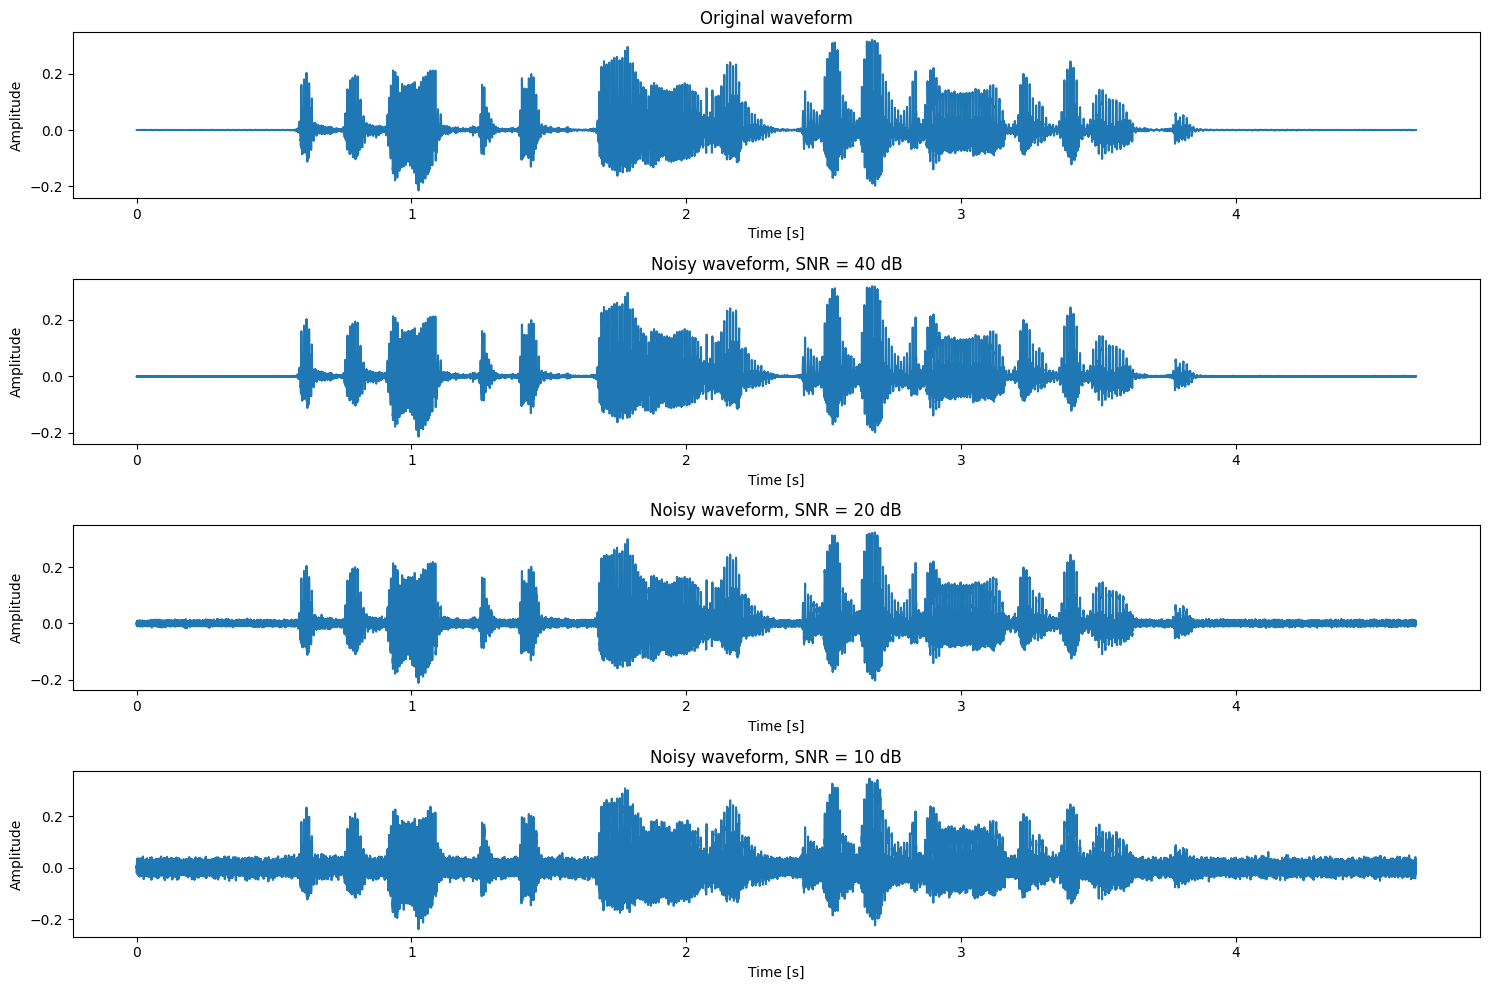

In [49]:
snr_levels = [40, 20, 10]  # w dB

for f in example_files:
    audio, sr = sf.read(f)
    
    plt.figure(figsize=(15, 10))
    
    # Oryginalna fala
    time = np.linspace(0, len(audio)/sr, num=len(audio))
    plt.subplot(len(snr_levels)+1, 1, 1)
    plt.plot(time, audio)
    plt.title("Original waveform")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    
    # Dodanie szumu dla każdego SNR
    for i, snr in enumerate(snr_levels, start=2):
        audio_noisy = add_awgn(audio, snr)
        
        plt.subplot(len(snr_levels)+1, 1, i)
        plt.plot(time, audio_noisy)
        plt.title(f"Noisy waveform, SNR = {snr} dB")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        
        # Opcjonalnie zapis pliku
        # out_file = f"{f.split('/')[-1].replace('.wav','')}_snr{snr}.wav"
        # sf.write(out_file, audio_noisy, sr)
    
    plt.tight_layout()
    plt.show()